In [12]:
import pandas as pd

# Define the path to your file
file_path = 'data/simulated_call_centre.csv'

try:
    # Read the CSV into a DataFrame
    df = pd.read_csv(file_path)
    
    # Print the first 5 rows to verify
    print(df.head())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

   call_id        date  daily_caller call_started call_answered  call_ended  \
0        1  2021-01-01             1   8:00:00 AM    8:00:00 AM  8:14:22 AM   
1        2  2021-01-01             2   8:02:42 AM    8:02:42 AM  8:07:31 AM   
2        3  2021-01-01             3   8:08:24 AM    8:08:24 AM  8:10:13 AM   
3        4  2021-01-01             4   8:09:37 AM    8:09:37 AM  8:13:45 AM   
4        5  2021-01-01             5   8:11:10 AM    8:11:10 AM  8:15:28 AM   

   wait_length  service_length  meets_standard  
0            0             863            True  
1            0             289            True  
2            0             108            True  
3            0             247            True  
4            0             258            True  


--- Initial Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51708 entries, 0 to 51707
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   call_id           51708 non-null  int64         
 1   date              51708 non-null  datetime64[ns]
 2   daily_caller      51708 non-null  int64         
 3   call_started      51708 non-null  object        
 4   call_answered     51708 non-null  object        
 5   call_ended        51708 non-null  object        
 6   wait_length       51708 non-null  int64         
 7   service_length    51708 non-null  int64         
 8   meets_standard    51708 non-null  bool          
 9   call_started_dt   51708 non-null  datetime64[ns]
 10  call_answered_dt  51708 non-null  datetime64[ns]
 11  call_ended_dt     51708 non-null  datetime64[ns]
dtypes: bool(1), datetime64[ns](4), int64(4), object(3)
memory usage: 4.4+ MB

--- Cleaned Data Info ---
<cla

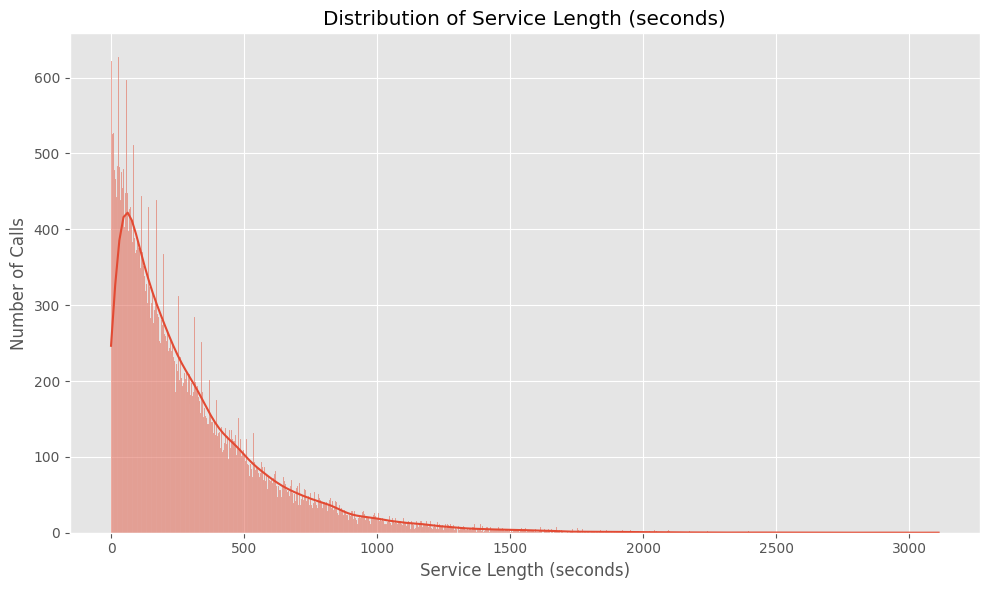

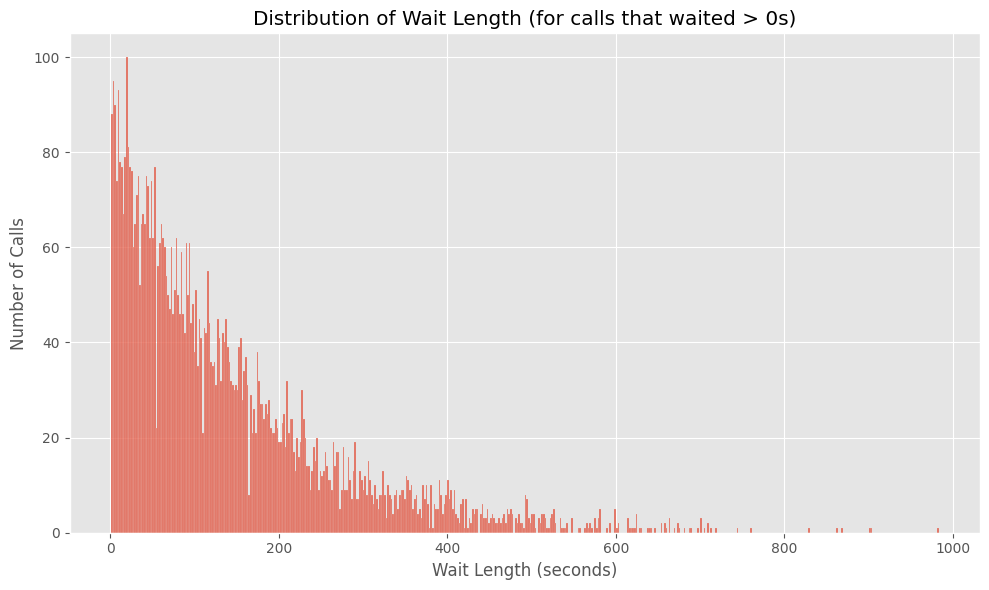

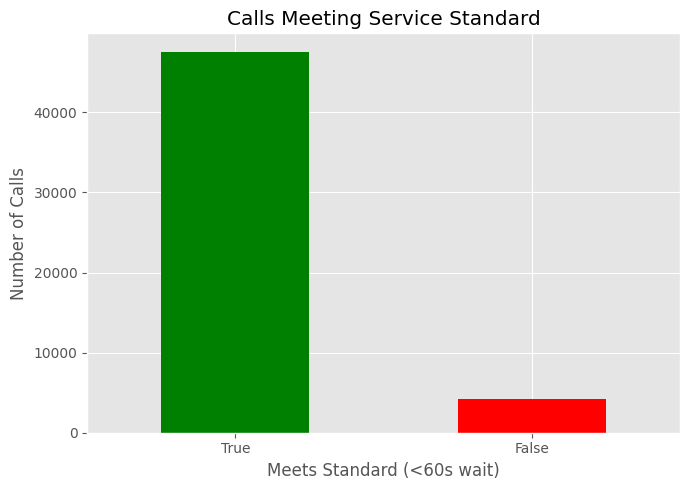

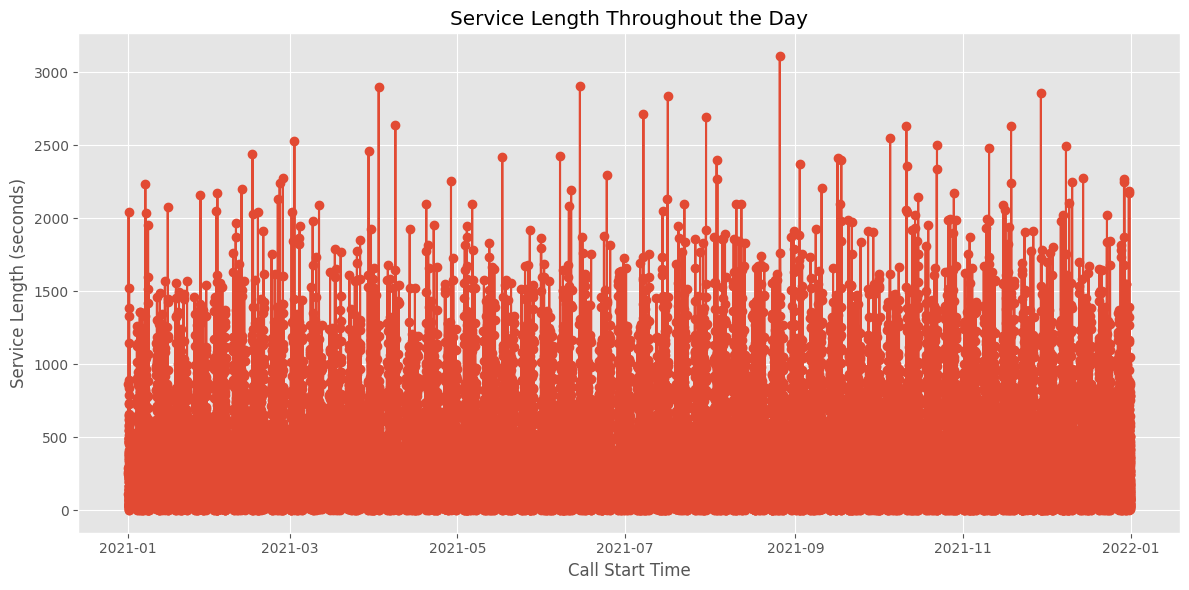

In [18]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. Inspect and Clean Data ---
print("--- Initial Data Info ---")
df.info()

# Convert date and time columns to datetime objects
df['date'] = pd.to_datetime(df['date'])
# Combine 'date' and 'call_started' to create a full timestamp
df['call_started_dt'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['call_started'])
df['call_answered_dt'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['call_answered'])
df['call_ended_dt'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['call_ended'])

# Normalize 'meets_standard' to boolean only if not already boolean
if df['meets_standard'].dtype != bool:
    df['meets_standard'] = (
        df['meets_standard']
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'true': True, 'false': False})
    )

print("\n--- Cleaned Data Info ---")
df.info()

print("\n--- Data Head ---")
print(df.head())

# --- 3. Descriptive Statistics ---
print("\n--- Descriptive Statistics (Numerical) ---")
# Describe numerical columns
print(df[['wait_length', 'service_length']].describe())

print("\n--- Service Standard Analysis ---")
# Reindex to ensure both True/False are present even if one is missing
standard_counts = df['meets_standard'].value_counts().reindex([True, False]).fillna(0).astype(int)
standard_percent = df['meets_standard'].value_counts(normalize=True).reindex([True, False]).fillna(0) * 100
print(standard_counts)
print(f"\nPercentage that meets standard: {standard_percent.loc[True]:.2f}%")
print(f"Percentage that DO NOT meet standard: {standard_percent.loc[False]:.2f}%")

# Key Metrics
avg_wait = df['wait_length'].mean()
avg_service = df['service_length'].mean()
total_calls = len(df)
total_waited = len(df[df['wait_length'] > 0])

print(f"\n--- Key Metrics ---")
print(f"Total Calls: {total_calls}")
print(f"Average Wait Length: {avg_wait:.2f} seconds")
print(f"Average Service Length: {avg_service:.2f} seconds")
print(f"Total Calls with Wait Time > 0: {total_waited}")


# --- 4. Visualizations ---
print("\n--- Generating Plots ---")
plt.style.use('ggplot')

# Plot 1: Distribution of Service Length
plt.figure(figsize=(10, 6))
sns.histplot(df['service_length'], kde=True, bins=1000)
plt.title('Distribution of Service Length (seconds)')
plt.xlabel('Service Length (seconds)')
plt.ylabel('Number of Calls')
plt.tight_layout()
plt.savefig('service_length_distribution.png')
print("Saved service_length_distribution.png")

# Plot 2: Distribution of Wait Length
# Most are 0, so let's plot only those that had to wait
df_waited = df[df['wait_length'] > 0]
if not df_waited.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_waited['wait_length'], kde=False, bins=500)
    plt.title('Distribution of Wait Length (for calls that waited > 0s)')
    plt.xlabel('Wait Length (seconds)')
    plt.ylabel('Number of Calls')
    plt.tight_layout()
    plt.savefig('wait_length_distribution.png')
    print("Saved wait_length_distribution.png")
else:
    print("No calls had a wait time > 0, skipping wait length plot.")

# Plot 3: Calls by 'meets_standard'
plt.figure(figsize=(7, 5))
standard_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Calls Meeting Service Standard')
plt.xlabel('Meets Standard (<60s wait)')
plt.ylabel('Number of Calls')
plt.xticks(ticks=[0, 1], labels=['True', 'False'], rotation=0)
plt.tight_layout()
plt.savefig('meets_standard_barchart.png')
print("Saved meets_standard_barchart.png")

# Plot 4: Service Length over Time
plt.figure(figsize=(12, 6))
plt.plot(df['call_started_dt'], df['service_length'], marker='o', linestyle='-')
plt.title('Service Length Throughout the Day')
plt.xlabel('Call Start Time')
plt.ylabel('Service Length (seconds)')
plt.grid(True)
plt.tight_layout()
plt.savefig('service_length_over_time.png')
print("Saved service_length_over_time.png")

print("\nAnalysis complete.")

In [14]:
# Inspect dtypes and preview key columns
import numpy as np

if 'df' in globals() and isinstance(df, pd.DataFrame) and not df.empty:
    print("Shape:", df.shape)
    cols = [c for c in ['date', 'wait_length', 'service_length', 'meets_standard'] if c in df.columns]
    display(df[cols].head(10))
    print("\nDtypes:\n", df.dtypes)
else:
    print("DataFrame 'df' not available. Please run the data loading cell above and ensure the file path is correct (e.g., 'data/simulated_call_centre.csv').")

Shape: (51708, 12)


,date,wait_length,service_length,meets_standard
0,2021-01-01,0,863,True
1,2021-01-01,0,289,True
2,2021-01-01,0,108,True
3,2021-01-01,0,247,True
4,2021-01-01,0,258,True
5,2021-01-01,0,340,True
6,2021-01-01,0,656,True
7,2021-01-01,0,341,True
8,2021-01-01,0,23,True
9,2021-01-01,0,582,True



Dtypes:
 call_id                      int64
date                datetime64[ns]
daily_caller                 int64
call_started                object
call_answered               object
call_ended                  object
wait_length                  int64
service_length               int64
meets_standard                bool
call_started_dt     datetime64[ns]
call_answered_dt    datetime64[ns]
call_ended_dt       datetime64[ns]
dtype: object


In [15]:
# Preprocess data: ensure correct path, dtypes, and boolean meets_standard
import pandas as pd
import numpy as np

# If df is missing or empty, try loading from the discovered path
if 'df' not in globals() or not isinstance(df, pd.DataFrame) or df.empty:
    candidate_paths = [
        'data/simulated_call_centre.csv',
        'data/call_center_data.csv',  # fallback if someone renamed
    ]
    for p in candidate_paths:
        try:
            df = pd.read_csv(p)
            print(f"Loaded: {p} -> shape {df.shape}")
            break
        except Exception as e:
            last_err = e
    else:
        raise RuntimeError(
            f"Could not load any candidate CSVs. Last error: {last_err}\nChecked: {candidate_paths}"
        )

# Normalize column names (strip whitespace)
df.columns = df.columns.str.strip()

# Parse date if present
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Ensure numeric columns
for c in ['wait_length', 'service_length']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Normalize or compute meets_standard (wait < 60 seconds)
if 'meets_standard' not in df.columns and 'wait_length' in df.columns:
    df['meets_standard'] = (df['wait_length'] < 60)
elif 'meets_standard' in df.columns:
    # Convert common truthy/falsey representations to proper booleans
    mapping = {
        'true': True, 'false': False,
        'yes': True, 'no': False,
        'y': True, 'n': False,
        't': True, 'f': False,
        1: True, 0: False
    }
    ser = df['meets_standard']
    if ser.dtype == object:
        ser_norm = ser.astype(str).str.strip().str.lower().map(mapping)
        if ser_norm.isna().any() and 'wait_length' in df.columns:
            ser_norm = ser_norm.fillna(df['wait_length'] < 60)
        df['meets_standard'] = ser_norm.astype(bool)
    elif ser.dtype != bool:
        df['meets_standard'] = ser.astype(int).map({1: True, 0: False}).fillna(False).astype(bool)

# Drop rows with missing key fields used in charts
key_cols = [c for c in ['date', 'wait_length', 'service_length', 'meets_standard'] if c in df.columns]
df = df.dropna(subset=key_cols)

print("Preprocessing complete. Head:")
display(df.head())
print("Dtypes:\n", df.dtypes)

Preprocessing complete. Head:


,call_id,date,daily_caller,call_started,call_answered,call_ended,wait_length,service_length,meets_standard,call_started_dt,call_answered_dt,call_ended_dt
0,1,2021-01-01,1,8:00:00 AM,8:00:00 AM,8:14:22 AM,0,863,True,2021-01-01 08:00:00,2021-01-01 08:00:00,2021-01-01 08:14:22
1,2,2021-01-01,2,8:02:42 AM,8:02:42 AM,8:07:31 AM,0,289,True,2021-01-01 08:02:42,2021-01-01 08:02:42,2021-01-01 08:07:31
2,3,2021-01-01,3,8:08:24 AM,8:08:24 AM,8:10:13 AM,0,108,True,2021-01-01 08:08:24,2021-01-01 08:08:24,2021-01-01 08:10:13
3,4,2021-01-01,4,8:09:37 AM,8:09:37 AM,8:13:45 AM,0,247,True,2021-01-01 08:09:37,2021-01-01 08:09:37,2021-01-01 08:13:45
4,5,2021-01-01,5,8:11:10 AM,8:11:10 AM,8:15:28 AM,0,258,True,2021-01-01 08:11:10,2021-01-01 08:11:10,2021-01-01 08:15:28


Dtypes:
 call_id                      int64
date                datetime64[ns]
daily_caller                 int64
call_started                object
call_answered               object
call_ended                  object
wait_length                  int64
service_length               int64
meets_standard                bool
call_started_dt     datetime64[ns]
call_answered_dt    datetime64[ns]
call_ended_dt       datetime64[ns]
dtype: object


In [ ]:
# Volume chart: concurrent calls over time (cumulative area)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

assert 'call_started_dt' in df.columns and 'call_ended_dt' in df.columns, "Run the preprocessing/analysis cell to create datetime columns."

# Build event series: +1 at start, -1 at end
starts = df[['call_started_dt']].rename(columns={'call_started_dt': 'ts'})
starts['delta'] = 1
ends = df[['call_ended_dt']].rename(columns={'call_ended_dt': 'ts'})
ends['delta'] = -1

# Concatenate and aggregate on identical timestamps
events = pd.concat([starts, ends], ignore_index=True).sort_values('ts')
series = events.groupby('ts', as_index=True)['delta'].sum().sort_index()

# Cumulative sum gives number of concurrent calls
concurrent = series.cumsum()

# Optional: resample to a regular grid for smoother plotting
freq = '1T'  # 1-minute resolution
concurrent_reg = concurrent.resample(freq).ffill().fillna(0).astype(int)

# Plot area chart over the full observed period
plt.figure(figsize=(14, 6))
ax = concurrent_reg.plot(kind='area', color=sns.color_palette('viridis', 10)[6], alpha=0.8)

# Make it a bit more colorful by shading by value using a colormap
# (optional enhancement: draw a line on top and use gradient fill imitation)
ax.plot(concurrent_reg.index, concurrent_reg.values, color='black', linewidth=1.0, alpha=0.8)

plt.title('Concurrent Calls Over Time (Cumulative Volume)')
plt.xlabel('Time')
plt.ylabel('Number of Active Calls')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# If you prefer stacked monthly colors, uncomment below to see per-month stackplot (visual load warning):
# monthly = []
# labels = []
# for month, g in df.groupby(df['date'].dt.to_period('M')):
#     s = pd.concat([
#         g[['call_started_dt']].rename(columns={'call_started_dt': 'ts'}).assign(delta=1),
#         g[['call_ended_dt']].rename(columns={'call_ended_dt': 'ts'}).assign(delta=-1)
#     ]).groupby('ts')['delta'].sum().sort_index().cumsum().resample(freq).ffill().fillna(0)
#     monthly.append(s)
#     labels.append(str(month))
# monthly_df = pd.concat(monthly, axis=1).fillna(0)
# monthly_df.columns = labels
# plt.figure(figsize=(14,6))
# plt.stackplot(monthly_df.index, monthly_df.T.values, labels=labels, colors=sns.color_palette('Spectral', len(labels)))
# plt.legend(ncol=4, fontsize=8)
# plt.title('Concurrent Calls Over Time by Month (Stacked Area)')
# plt.xlabel('Time')
# plt.ylabel('Number of Active Calls')
# plt.tight_layout()
# plt.show()

In [25]:
import simpy
import random
import statistics
import numpy as np  # <-- NEW
from scipy import stats  # <-- NEW
from collections import namedtuple

# --- 1. Simulation Parameters ---

RANDOM_SEED = 42
NUM_SIMULATIONS = 1000       # <-- NEW: Number of runs
NUM_AGENTS = 5
PATIENCE_SECONDS = 160
SIM_TIME = 8 * 60 * 60
SLA_THRESHOLD = 20

# --- 2. Call Arrival Model (Non-Homogeneous Poisson) ---
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0

# --- 3. Call Duration Model Sec---
AVG_CALL_DURATION = 240

# --- 4. Data Structures ---
Call = namedtuple("Call", ["call_id", "arrival_time", "call_duration"])

class Agent:
    def __init__(self, agent_id):
        self.agent_id = agent_id
        self.total_handle_time = 0.0

# --- 5. KPI Collector Class ---

# <-- MODIFIED: Class is refactored to calculate and return results
class KPIs:
    def __init__(self, agent_list):
        self.total_arrivals = 0
        self.total_answered = 0
        self.total_abandoned = 0
        self.wait_times = []
        self.sla_met_count = 0
        self.total_handle_time = 0.0
        self.agent_list = agent_list

    def calculate_results(self, total_sim_time):
        """
        Calculates all final KPIs and returns them in a dictionary.
        This is called *after* a simulation run is complete.
        """
        results = {}

        # Abandonment Rate
        if self.total_arrivals > 0:
            results['abandon_rate'] = (self.total_abandoned / self.total_arrivals) * 100
        else:
            results['abandon_rate'] = 0.0

        # SLA and ASA
        if self.total_answered > 0:
            results['asa'] = statistics.mean(self.wait_times)
            results['sla'] = (self.sla_met_count / self.total_answered) * 100
        else:
            results['asa'] = 0.0
            results['sla'] = 0.0  # Or np.nan if you prefer

        # Agent Utilization
        if total_sim_time > 0 and len(self.agent_list) > 0:
            total_agent_seconds_available = len(self.agent_list) * total_sim_time
            results['utilization'] = (self.total_handle_time / total_agent_seconds_available) * 100
        else:
            results['utilization'] = 0.0
            
        return results

# --- 6. Distribution Sampling Functions (Unchanged) ---

def sample_interarrival_time(current_time_seconds):
    current_hour = int(current_time_seconds // 3600) % 24
    rate_lambda = HOURLY_RATES_PER_SEC.get(current_hour, DEFAULT_RATE_PER_SEC)
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration():
    rate_lambda = 1.0 / AVG_CALL_DURATION
    return random.expovariate(rate_lambda)


# --- 7. Pre-Generation Function (Unchanged) ---

def pre_generate_calls(sim_duration):
    # print("Pre-generating call list...") # <-- Silenced for loops
    call_list = []
    call_id_counter = 0
    current_time = 0.0
    while current_time < sim_duration:
        time_to_next_call = sample_interarrival_time(current_time)
        arrival_time = current_time + time_to_next_call
        if arrival_time > sim_duration:
            break
        call_duration = sample_call_duration()
        call_id_counter += 1
        call_list.append(
            Call(call_id=call_id_counter,
                 arrival_time=arrival_time,
                 call_duration=call_duration)
        )
        current_time = arrival_time
    # print(f"Generated {len(call_list)} calls.") # <-- Silenced for loops
    return call_list


# --- 8. The "Call" Process ---

def call_process(env, call, agent_store, kpis):
    """
    Defines the life cycle of a single call.
    """
    arrival_time = env.now
    call_duration = call.call_duration
    get_agent_request = agent_store.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)

    # <-- IMPORTANT: All print() statements in this function are
    #     commented out to speed up the 10,000-run simulation.
    
    # print(f"[{env.now:.2f}s] Event: 'call arrive' (Call {call.call_id})")

    result = yield get_agent_request | patience_timeout

    if get_agent_request in result:
        # --- Event: 'call answered' ---
        agent = get_agent_request.value 
        wait_time = env.now - arrival_time
        # print(f"[{env.now:.2f}s] Event: 'call answered' (Call {call.call_id}) ...")

        kpis.total_answered += 1
        kpis.wait_times.append(wait_time)
        if wait_time <= SLA_THRESHOLD:
            kpis.sla_met_count += 1
        
        kpis.total_handle_time += call_duration
        agent.total_handle_time += call_duration

        yield env.timeout(call_duration)

        # --- Event: 'call finished' ---
        # print(f"[{env.now:.2f}s] Event: 'call finished' (Call {call.call_id}) ...")
        yield agent_store.put(agent)

    else:
        # --- Event: 'call abandoned' ---
        # print(f"[{env.now:.2f}s] Event: 'call abandoned' (Call {call.call_id})")
        kpis.total_abandoned += 1
        get_agent_request.cancel()


# --- 9. The "Call Generator" Process (Unchanged) ---

def call_generator(env, agent_store, kpis, call_list):
    for call in call_list:
        time_to_wait = call.arrival_time - env.now
        if time_to_wait > 0:
            yield env.timeout(time_to_wait)
        kpis.total_arrivals += 1
        env.process(call_process(env, call, agent_store, kpis))


# --- 10. NEW: Statistics Reporting Function ---

def get_confidence_interval(data, confidence=0.95):
    """Calculates the mean and 95% CI for a list of data."""
    if not data:
        return 0, 0, 0
    
    n = len(data)
    mean = np.mean(data)
    sem = stats.sem(data)  # Standard Error of the Mean
    
    if sem == 0:
        return mean, mean, mean # No variance
        
    # Get the t-distribution percentile for the CI
    h = sem * stats.t.ppf((1 + confidence) / 2., n - 1)
    
    return mean, mean - h, mean + h

def print_final_statistics(results_store):
    """Calculates and prints the final statistics with 95% CIs."""
    
    print("\n" + "="*50)
    print(f"--- Monte Carlo Simulation Results ({NUM_SIMULATIONS} runs) ---")
    print(f"Configuration: {NUM_AGENTS} agents, {PATIENCE_SECONDS}s patience")
    print("All results are given as: Mean (95% Confidence Interval)")
    print("="*50)

    # 1. Abandonment Rate
    data = results_store['abandon_rate']
    mean, low, high = get_confidence_interval(data)
    print(f"Abandonment Rate: {mean:6.3f}% ({low:6.3f}% - {high:6.3f}%)")
    
    # 2. Service Level (SLA)
    data = results_store['sla']
    mean, low, high = get_confidence_interval(data)
    print(f"Service Level ({SLA_THRESHOLD}s): {mean:6.3f}% ({low:6.3f}% - {high:6.3f}%)")

    # 3. Average Speed of Answer (ASA)
    data = results_store['asa']
    mean, low, high = get_confidence_interval(data)
    print(f"Avg. Speed of Answer: {mean:6.3f}s ({low:6.3f}s - {high:6.3f}s)")
    
    # 4. Agent Utilization
    data = results_store['utilization']
    mean, low, high = get_confidence_interval(data)
    print(f"Overall Utilization:  {mean:6.3f}% ({low:6.3f}% - {high:6.3f}%)")
    
    print("="*50)


# --- 11. Main Simulation Execution ---

if __name__ == "__main__":
    print(f"--- Starting Monte Carlo Simulation ---")
    print(f"Running {NUM_SIMULATIONS} replications...")
    
    # Set the random seed ONCE. This makes the *entire experiment*
    # reproducible, while each run within it is unique.
    random.seed(RANDOM_SEED)

    # NEW: Store for all results
    all_results = {
        'abandon_rate': [],
        'sla': [],
        'asa': [],
        'utilization': [],
    }

    # The main simulation loop
    for i in range(NUM_SIMULATIONS):
        if (i + 1) % (NUM_SIMULATIONS // 10) == 0:
            print(f"  ... completed run {i + 1}/{NUM_SIMULATIONS}")

        # --- Setup: Must reset everything for each run ---
        
        # 1. Generate a NEW call trace for this run
        call_trace = pre_generate_calls(SIM_TIME)

        # 2. Create NEW agents
        agent_objects = [Agent(agent_id=f"Agent-{j+1:02d}") for j in range(NUM_AGENTS)]

        # 3. Create a NEW KPI tracker
        kpis = KPIs(agent_list=agent_objects)

        # 4. Create a NEW environment
        env = simpy.Environment()

        # 5. Create a NEW agent pool
        agent_pool = simpy.Store(env)
        agent_pool.items = agent_objects[:]

        # 6. Start the call generator
        env.process(call_generator(env, agent_pool, kpis, call_trace))

        # 7. Run the simulation
        env.run(until=SIM_TIME)
        
        # --- Collect Results ---
        run_results = kpis.calculate_results(SIM_TIME)
        
        all_results['abandon_rate'].append(run_results['abandon_rate'])
        all_results['sla'].append(run_results['sla'])
        all_results['asa'].append(run_results['asa'])
        all_results['utilization'].append(run_results['utilization'])

    # --- 8. Print Final Report ---
    print("All simulations complete.")
    print_final_statistics(all_results)

--- Starting Monte Carlo Simulation ---
Running 1000 replications...
  ... completed run 100/1000
  ... completed run 200/1000
  ... completed run 300/1000
  ... completed run 400/1000
  ... completed run 500/1000
  ... completed run 600/1000
  ... completed run 700/1000
  ... completed run 800/1000
  ... completed run 900/1000
  ... completed run 1000/1000
All simulations complete.

--- Monte Carlo Simulation Results (1000 runs) ---
Configuration: 5 agents, 160s patience
All results are given as: Mean (95% Confidence Interval)
Abandonment Rate: 15.607% (15.357% - 15.858%)
Service Level (20s): 67.848% (67.544% - 68.152%)
Avg. Speed of Answer: 32.924s (32.575s - 33.273s)
Overall Utilization:  40.325% (40.146% - 40.504%)


Starting experiment: Testing 1 to 20 agents.
Running 1000 replications per step...
  ... Completed 1 agents. Mean SLA: 48.49%, Mean Abandon: 73.13%
  ... Completed 2 agents. Mean SLA: 56.18%, Mean Abandon: 54.10%
  ... Completed 3 agents. Mean SLA: 61.55%, Mean Abandon: 40.62%
  ... Completed 4 agents. Mean SLA: 65.74%, Mean Abandon: 30.55%
  ... Completed 5 agents. Mean SLA: 69.49%, Mean Abandon: 23.17%
  ... Completed 6 agents. Mean SLA: 72.27%, Mean Abandon: 17.44%
  ... Completed 7 agents. Mean SLA: 75.25%, Mean Abandon: 12.93%
  ... Completed 8 agents. Mean SLA: 78.62%, Mean Abandon: 8.96%
  ... Completed 9 agents. Mean SLA: 81.59%, Mean Abandon: 6.16%
  ... Completed 10 agents. Mean SLA: 85.46%, Mean Abandon: 3.88%
  ... Completed 11 agents. Mean SLA: 88.79%, Mean Abandon: 2.39%
  ... Completed 12 agents. Mean SLA: 91.96%, Mean Abandon: 1.24%
  ... Completed 13 agents. Mean SLA: 94.57%, Mean Abandon: 0.67%
  ... Completed 14 agents. Mean SLA: 96.71%, Mean Abandon: 0.31%
  ... Com

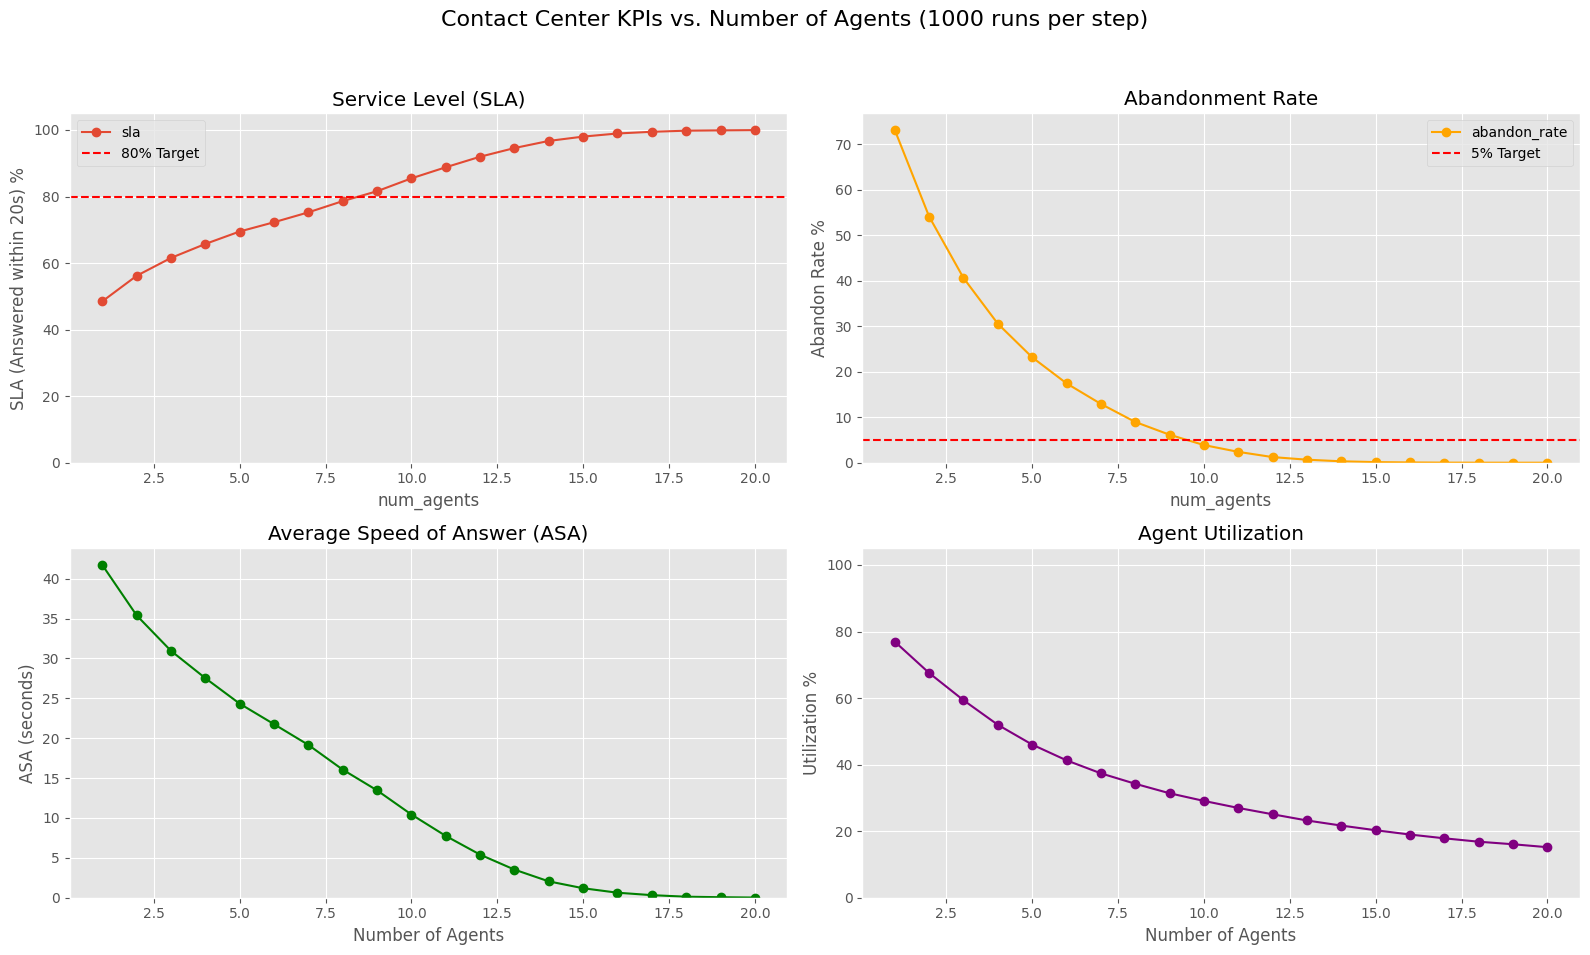

In [26]:
import simpy
import random
import statistics
import numpy as np
from scipy import stats
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Simulation Parameters ---

# Note: Set to a lower number (e.g., 100-500) for a quick plot.
# Set higher (1000+) for more accurate, smoother curves.
NUM_REPLICATIONS_PER_STEP = 1000  # Number of runs for *each* agent count
PATIENCE_SECONDS = 120
SIM_TIME = 8 * 60 * 60        # Simulate for 8 hours (in seconds)
SLA_THRESHOLD = 20

# Agent counts to test
MIN_AGENTS = 1
MAX_AGENTS = 20

# --- 2. Call Arrival & Duration Models ---
HOURLY_CALL_RATES = {
    # Hour: Calls per Hour
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0
AVG_CALL_DURATION = 300       # Avg. call lasts 300 seconds (5 minutes)

# --- 3. Data Structures ---
Call = namedtuple("Call", ["call_id", "arrival_time", "call_duration"])

class Agent:
    def __init__(self, agent_id):
        self.agent_id = agent_id
        self.total_handle_time = 0.0

# --- 4. KPI Collector Class ---
class KPIs:
    """A simple class to store and calculate simulation results."""
    def __init__(self, agent_list):
        self.total_arrivals = 0
        self.total_answered = 0
        self.total_abandoned = 0
        self.wait_times = []
        self.sla_met_count = 0
        self.total_handle_time = 0.0
        self.agent_list = agent_list

    def calculate_results(self, total_sim_time):
        """Calculates all final KPIs and returns them in a dictionary."""
        results = {}
        if self.total_arrivals > 0:
            results['abandon_rate'] = (self.total_abandoned / self.total_arrivals) * 100
        else:
            results['abandon_rate'] = 0.0

        if self.total_answered > 0:
            results['asa'] = statistics.mean(self.wait_times)
            results['sla'] = (self.sla_met_count / self.total_answered) * 100
        else:
            results['asa'] = np.nan # Use NaN for no answered calls
            results['sla'] = np.nan

        if total_sim_time > 0 and len(self.agent_list) > 0:
            total_agent_seconds_available = len(self.agent_list) * total_sim_time
            results['utilization'] = (self.total_handle_time / total_agent_seconds_available) * 100
        else:
            results['utilization'] = 0.0
        return results

# --- 5. Distribution Sampling Functions ---
def sample_interarrival_time(current_time_seconds):
    """Samples inter-arrival time based on the time of day."""
    current_hour = int(current_time_seconds // 3600) % 24
    rate_lambda = HOURLY_RATES_PER_SEC.get(current_hour, DEFAULT_RATE_PER_SEC)
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration():
    """Samples the duration of a call (service time)."""
    rate_lambda = 1.0 / AVG_CALL_DURATION
    return random.expovariate(rate_lambda)

# --- 6. Pre-Generation Function ---
def pre_generate_calls(sim_duration):
    """Generates a list of all call arrivals."""
    call_list = []
    call_id_counter = 0
    current_time = 0.0
    while current_time < sim_duration:
        time_to_next_call = sample_interarrival_time(current_time)
        arrival_time = current_time + time_to_next_call
        if arrival_time > sim_duration: break
        call_duration = sample_call_duration()
        call_id_counter += 1
        call_list.append(
            Call(call_id=call_id_counter,
                 arrival_time=arrival_time,
                 call_duration=call_duration)
        )
        current_time = arrival_time
    return call_list

# --- 7. The "Call" Process ---
def call_process(env, call, agent_store, kpis):
    """Defines the life cycle of a single call."""
    arrival_time = env.now
    call_duration = call.call_duration
    get_agent_request = agent_store.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)
    
    result = yield get_agent_request | patience_timeout

    if get_agent_request in result:
        # --- Call Answered ---
        agent = get_agent_request.value 
        wait_time = env.now - arrival_time

        kpis.total_answered += 1
        kpis.wait_times.append(wait_time)
        if wait_time <= SLA_THRESHOLD:
            kpis.sla_met_count += 1
        
        kpis.total_handle_time += call_duration
        agent.total_handle_time += call_duration

        yield env.timeout(call_duration)
        yield agent_store.put(agent) # Release agent
    else:
        # --- Call Abandoned ---
        kpis.total_abandoned += 1
        get_agent_request.cancel()

# --- 8. The "Call Generator" Process ---
def call_generator(env, agent_store, kpis, call_list):
    """Reads from the pre-generated list and starts call processes."""
    for call in call_list:
        time_to_wait = call.arrival_time - env.now
        if time_to_wait > 0:
            yield env.timeout(time_to_wait)
        kpis.total_arrivals += 1
        env.process(call_process(env, call, agent_store, kpis))

# --- 9. Single Simulation Run Function ---
def run_one_simulation_replica(num_agents, sim_duration):
    """Runs one full simulation (one 8-hour day) and returns its KPIs."""
    
    call_trace = pre_generate_calls(sim_duration)
    agent_objects = [Agent(agent_id=f"Agent-{j+1:02d}") for j in range(num_agents)]
    kpis = KPIs(agent_list=agent_objects)
    env = simpy.Environment()
    agent_pool = simpy.Store(env)
    agent_pool.items = agent_objects[:]
    
    env.process(call_generator(env, agent_pool, kpis, call_trace))
    env.run(until=sim_duration)
    
    return kpis.calculate_results(sim_duration)

# --- 10. Main Experiment Loop ---
def run_experiment(min_agents, max_agents, num_replications, sim_duration):
    """
    Runs a Monte Carlo simulation for each agent count from min to max.
    Returns a DataFrame with the mean KPIs for each agent count.
    """
    print(f"Starting experiment: Testing {min_agents} to {max_agents} agents.")
    print(f"Running {num_replications} replications per step...")
    
    experiment_results = []
    
    # This is the main loop that iterates through agent counts
    for n_agents in range(min_agents, max_agents + 1):
        
        replication_results = {
            'abandon_rate': [], 'sla': [], 'asa': [], 'utilization': [],
        }
        
        # Run the Monte Carlo loop
        for i in range(num_replications):
            # We set a new random seed for *each* replication to ensure
            # they are independent.
            random.seed(i + n_agents * num_replications) # Unique seed
            
            run_kpis = run_one_simulation_replica(n_agents, sim_duration)
            
            replication_results['abandon_rate'].append(run_kpis['abandon_rate'])
            replication_results['sla'].append(run_kpis['sla'])
            replication_results['asa'].append(run_kpis['asa'])
            replication_results['utilization'].append(run_kpis['utilization'])

        # Calculate the mean KPIs for this agent count
        # We use np.nanmean to safely ignore NaNs (e.g., if no calls were
        # answered when N=1, ASA will be NaN)
        mean_kpis = {
            'num_agents': n_agents,
            'sla': np.nanmean(replication_results['sla']),
            'abandon_rate': np.nanmean(replication_results['abandon_rate']),
            'asa': np.nanmean(replication_results['asa']),
            'utilization': np.nanmean(replication_results['utilization'])
        }
        
        experiment_results.append(mean_kpis)
        print(f"  ... Completed {n_agents} agents. "
              f"Mean SLA: {mean_kpis['sla']:.2f}%, "
              f"Mean Abandon: {mean_kpis['abandon_rate']:.2f}%")
        
    print("Experiment complete.")
    return pd.DataFrame(experiment_results).set_index('num_agents')

# --- 11. Plotting Function ---
def create_plots(df):
    """Creates and saves plots from the results DataFrame."""
    print("Generating plots...")
    
    # Create a 2x2 grid of plots
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
    fig.suptitle(f'Contact Center KPIs vs. Number of Agents ({NUM_REPLICATIONS_PER_STEP} runs per step)', fontsize=16)

    # --- Plot 1: SLA (Service Level) ---
    df['sla'].plot(ax=axes[0, 0], grid=True, marker='o')
    axes[0, 0].set_title('Service Level (SLA)')
    axes[0, 0].set_ylabel(f'SLA (Answered within {SLA_THRESHOLD}s) %')
    axes[0, 0].axhline(y=80, color='r', linestyle='--', label='80% Target')
    axes[0, 0].legend()
    axes[0, 0].set_ylim(0, 105)

    # --- Plot 2: Abandonment Rate ---
    df['abandon_rate'].plot(ax=axes[0, 1], grid=True, marker='o', color='orange')
    axes[0, 1].set_title('Abandonment Rate')
    axes[0, 1].set_ylabel('Abandon Rate %')
    axes[0, 1].axhline(y=5, color='r', linestyle='--', label='5% Target')
    axes[0, 1].legend()
    axes[0, 1].set_ylim(bottom=0)

    # --- Plot 3: Average Speed of Answer (ASA) ---
    df['asa'].plot(ax=axes[1, 0], grid=True, marker='o', color='green')
    axes[1, 0].set_title('Average Speed of Answer (ASA)')
    axes[1, 0].set_ylabel('ASA (seconds)')
    axes[1, 0].set_xlabel('Number of Agents')
    axes[1, 0].set_ylim(bottom=0)

    # --- Plot 4: Agent Utilization ---
    df['utilization'].plot(ax=axes[1, 1], grid=True, marker='o', color='purple')
    axes[1, 1].set_title('Agent Utilization')
    axes[1, 1].set_ylabel('Utilization %')
    axes[1, 1].set_xlabel('Number of Agents')
    axes[1, 1].set_ylim(0, 105)
    
    # Improve layout and save
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('contact_center_kpi_plots.png')
    print("Plots saved to 'contact_center_kpi_plots.png'")

# --- 12. Main Execution ---
if __name__ == "__main__":
    # Note: Using a single global seed for the *start* of the experiment
    # makes the *entire set* of runs reproducible.
    random.seed(42) 
    
    results_df = run_experiment(
        min_agents=MIN_AGENTS,
        max_agents=MAX_AGENTS,
        num_replications=NUM_REPLICATIONS_PER_STEP,
        sim_duration=SIM_TIME
    )
    
    print("\n--- Experiment Results (Mean KPIs) ---")
    print(results_df)
    
    create_plots(results_df)

--- Starting Hourly Staffing Optimization (Binary Search) ---
Constraints: SLA >= 80.0%, Abandon <= 5.0%
Running 100 replications per test step.

--- Testing Hour 00 (Rate: 30.0 calls/hr) ---
  N=15: Mean SLA: 100.00%, Mean Abandon:   0.00% -> OK.
  N= 7: Mean SLA:  99.53%, Mean Abandon:   0.00% -> OK.
  N= 3: Mean SLA:  77.20%, Mean Abandon:  17.25% -> (Fails constraints)
  N= 5: Mean SLA:  95.99%, Mean Abandon:   0.99% -> OK.
  N= 4: Mean SLA:  88.51%, Mean Abandon:   5.25% -> (Fails constraints)
  -> Optimal N for Hour 00 is 5

--- Testing Hour 01 (Rate: 20.0 calls/hr) ---
  N=15: Mean SLA: 100.00%, Mean Abandon:   0.00% -> OK.
  N= 7: Mean SLA:  99.79%, Mean Abandon:   0.00% -> OK.
  N= 3: Mean SLA:  90.85%, Mean Abandon:   6.69% -> (Fails constraints)
  N= 5: Mean SLA:  98.68%, Mean Abandon:   0.36% -> OK.
  N= 4: Mean SLA:  96.23%, Mean Abandon:   1.62% -> OK.
  -> Optimal N for Hour 01 is 4

--- Testing Hour 02 (Rate: 10.0 calls/hr) ---
  N=15: Mean SLA: 100.00%, Mean Abandon:  

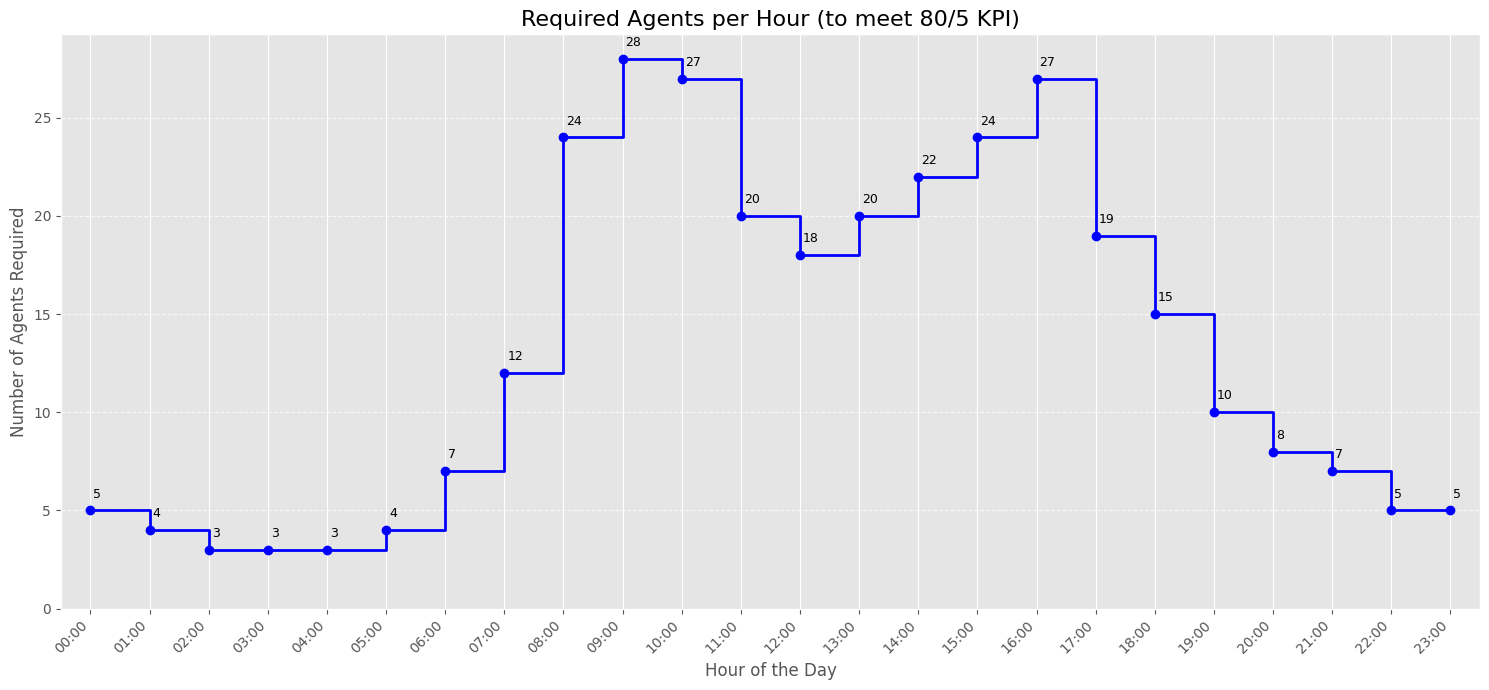

In [33]:
import simpy
import random
import statistics
import numpy as np
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Simulation Parameters ---

NUM_REPLICATIONS_PER_HOUR = 100
PATIENCE_SECONDS = 120
SLA_THRESHOLD = 20
SIM_DURATION_PER_HOUR = 3600

MIN_AGENTS_TO_TEST = 1
MAX_AGENTS_TO_TEST = 30 # Max agents to try for any given hour

# --- 2. Call Arrival & Duration Models ---
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0
AVG_CALL_DURATION = 300

# --- 3. Data Structures ---
Call = namedtuple("Call", ["call_id", "arrival_time", "call_duration"])
class Agent:
    def __init__(self, agent_id):
        self.agent_id = agent_id
        self.total_handle_time = 0.0

# --- 4. KPI Collector Class (Unchanged) ---
class KPIs:
    def __init__(self, agent_list):
        self.total_arrivals = 0
        self.total_answered = 0
        self.total_abandoned = 0
        self.wait_times = []
        self.sla_met_count = 0
        self.total_handle_time = 0.0
        self.agent_list = agent_list

    def calculate_results(self, total_sim_time):
        results = {}
        if self.total_arrivals > 0:
            results['abandon_rate'] = (self.total_abandoned / self.total_arrivals) * 100
        else:
            results['abandon_rate'] = 0.0

        if self.total_answered > 0:
            results['asa'] = statistics.mean(self.wait_times)
            results['sla'] = (self.sla_met_count / self.total_answered) * 100
        else:
            results['asa'] = np.nan
            results['sla'] = np.nan
        return results

# --- 5. Distribution Sampling Functions (Unchanged) ---
def sample_interarrival_time(rate_lambda):
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration():
    rate_lambda = 1.0 / AVG_CALL_DURATION
    return random.expovariate(rate_lambda)

# --- 6. Pre-Generation Function (Unchanged) ---
def pre_generate_calls(sim_duration, rate_lambda):
    call_list = []
    call_id_counter = 0
    current_time = 0.0
    while current_time < sim_duration:
        time_to_next_call = sample_interarrival_time(rate_lambda)
        arrival_time = current_time + time_to_next_call
        if arrival_time > sim_duration: break
        call_duration = sample_call_duration()
        call_id_counter += 1
        call_list.append(
            Call(call_id=call_id_counter,
                 arrival_time=arrival_time,
                 call_duration=call_duration)
        )
        current_time = arrival_time
    return call_list

# --- 7. The "Call" Process (Unchanged) ---
def call_process(env, call, agent_store, kpis):
    arrival_time = env.now
    call_duration = call.call_duration
    get_agent_request = agent_store.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)
    
    result = yield get_agent_request | patience_timeout
    if get_agent_request in result:
        agent = get_agent_request.value 
        wait_time = env.now - arrival_time
        kpis.total_answered += 1
        kpis.wait_times.append(wait_time)
        if wait_time <= SLA_THRESHOLD: kpis.sla_met_count += 1
        agent.total_handle_time += call_duration
        yield env.timeout(call_duration)
        yield agent_store.put(agent)
    else:
        kpis.total_abandoned += 1
        get_agent_request.cancel()

# --- 8. The "Call Generator" Process (Unchanged) ---
def call_generator(env, agent_store, kpis, call_list):
    for call in call_list:
        time_to_wait = call.arrival_time - env.now
        if time_to_wait > 0: yield env.timeout(time_to_wait)
        kpis.total_arrivals += 1
        env.process(call_process(env, call, agent_store, kpis))

# --- 9. Single Simulation Run Function (Unchanged) ---
def run_one_simulation_replica(num_agents, sim_duration, rate_lambda):
    call_trace = pre_generate_calls(sim_duration, rate_lambda)
    agent_objects = [Agent(f"Agent-{j+1}") for j in range(num_agents)]
    kpis = KPIs(agent_list=agent_objects)
    env = simpy.Environment()
    agent_pool = simpy.Store(env)
    agent_pool.items = agent_objects[:]
    
    env.process(call_generator(env, agent_pool, kpis, call_trace))
    env.run(until=sim_duration)
    
    return kpis.calculate_results(sim_duration)

# --- 10. NEW: Helper Function for Binary Search ---
def check_kpis_for_n_agents(hour, n_agents, rate_for_hour, sla_target, abandon_target):
    """
    Runs all replications for a single N and returns True (Pass) or False (Fail).
    """
    replication_kpis = []
    for i in range(NUM_REPLICATIONS_PER_HOUR):
        random.seed(i + hour*1000 + n_agents*100) # Unique seed
        kpis = run_one_simulation_replica(
            num_agents=n_agents,
            sim_duration=SIM_DURATION_PER_HOUR,
            rate_lambda=rate_for_hour
        )
        replication_kpis.append(kpis)

    mean_sla = np.nanmean([r['sla'] for r in replication_kpis])
    mean_abandon = np.nanmean([r['abandon_rate'] for r in replication_kpis])

    print(f"  N={n_agents:2d}: Mean SLA: {mean_sla:6.2f}%, Mean Abandon: {mean_abandon:6.2f}%", end="")
    
    if mean_sla >= sla_target and mean_abandon <= abandon_target:
        print(" -> OK.")
        return True
    else:
        print(" -> (Fails constraints)")
        return False

# --- 11. MODIFIED: Optimization Function with Binary Search ---
def find_hourly_staffing(sla_target=80.0, abandon_target=5.0):
    """
    Runs the optimization using a binary search to find the min agents.
    """
    print("--- Starting Hourly Staffing Optimization (Binary Search) ---")
    print(f"Constraints: SLA >= {sla_target}%, Abandon <= {abandon_target}%")
    print(f"Running {NUM_REPLICATIONS_PER_HOUR} replications per test step.")
    
    staffing_results = []

    # Outer loop: Iterate through each hour
    for hour in range(24):
        rate_for_hour = HOURLY_RATES_PER_SEC.get(hour, DEFAULT_RATE_PER_SEC)
        
        if rate_for_hour <= 0:
            print(f"Hour {hour:02d}: No calls. Agents required: 0")
            staffing_results.append({'hour': hour, 'agents_required': 0})
            continue

        print(f"\n--- Testing Hour {hour:02d} (Rate: {rate_for_hour*3600:.1f} calls/hr) ---")
        
        # --- Binary Search Logic ---
        low = MIN_AGENTS_TO_TEST
        high = MAX_AGENTS_TO_TEST
        best_n = np.nan # Use np.nan as "not found"
        
        while low <= high:
            mid_n = (low + high) // 2
            
            # Check if this 'mid_n' is a feasible solution
            is_feasible = check_kpis_for_n_agents(
                hour, mid_n, rate_for_hour, sla_target, abandon_target
            )
            
            if is_feasible:
                # This N works. It's a *potential* answer.
                # But we need the *lowest* N, so try searching lower.
                best_n = mid_n      # Store this as the best solution so far
                high = mid_n - 1     # Try to find an even smaller N
            else:
                # This N failed. We need more agents.
                low = mid_n + 1
        
        # After the loop, best_n holds the smallest N that worked
        if not pd.isna(best_n):
             print(f"  -> Optimal N for Hour {hour:02d} is {best_n}")
             staffing_results.append({'hour': hour, 'agents_required': best_n})
        else:
             print(f"  WARNING: No solution found for Hour {hour:02d} within test range.")
             staffing_results.append({'hour': hour, 'agents_required': np.nan})
            
    print("\n--- Optimization Complete ---")
    return pd.DataFrame(staffing_results).set_index('hour')

# --- 12. Plotting Function (Unchanged) ---
def plot_hourly_staffing(df):
    """Creates and saves a step plot of required agents per hour."""
    print("Generating hourly staffing plot...")
    
    plt.figure(figsize=(15, 7))
    hours = df.index.values
    agents_required = df['agents_required'].values
    
    plt.step(hours, agents_required, where='post', color='blue', linestyle='-', linewidth=2)
    plt.plot(hours, agents_required, 'o', color='blue')
    
    for h, n in zip(hours, agents_required):
        if not pd.isna(n):
            plt.text(h + 0.05, n + 0.5, f'{int(n)}', 
                     verticalalignment='bottom', horizontalalignment='left',
                     color='black', fontsize=9)
    
    plt.title('Required Agents per Hour (to meet 80/5 KPI)', fontsize=16)
    plt.ylabel('Number of Agents Required', fontsize=12)
    plt.xlabel('Hour of the Day', fontsize=12)
    
    plt.xticks(
        ticks=np.arange(0, 24, 1),
        labels=[f"{h:02d}:00" for h in range(24)],
        rotation=45,
        ha='right'
    )
    plt.xlim(-0.5, 23.5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.savefig('hourly_staffing_requirements_step_plot.png')
    print("Plot saved to 'hourly_staffing_requirements_step_plot.png'")


# --- 13. Main Execution (Unchanged) ---
if __name__ == "__main__":
    random.seed(42)
    
    staffing_df = find_hourly_staffing()
    
    print("\n--- Final Staffing Plan ---")
    print(staffing_df)
    
    plot_hourly_staffing(staffing_df)

--- Starting Hourly Staffing Optimization (Binary Search) ---
AGENT CAP: Max 25 agents allowed per hour.

--- Testing Hour 00 (Rate: 30.0 calls/hr) ---
  -> Optimal N for Hour 00 is 5

--- Testing Hour 01 (Rate: 20.0 calls/hr) ---
  -> Optimal N for Hour 01 is 4

--- Testing Hour 02 (Rate: 10.0 calls/hr) ---
  -> Optimal N for Hour 02 is 3

--- Testing Hour 03 (Rate: 10.0 calls/hr) ---
  -> Optimal N for Hour 03 is 3

--- Testing Hour 04 (Rate: 15.0 calls/hr) ---
  -> Optimal N for Hour 04 is 3

--- Testing Hour 05 (Rate: 30.0 calls/hr) ---
  -> Optimal N for Hour 05 is 4

--- Testing Hour 06 (Rate: 60.0 calls/hr) ---
  -> Optimal N for Hour 06 is 7

--- Testing Hour 07 (Rate: 120.0 calls/hr) ---
  -> Optimal N for Hour 07 is 12

--- Testing Hour 08 (Rate: 250.0 calls/hr) ---
  -> Optimal N for Hour 08 is 24

--- Testing Hour 09 (Rate: 300.0 calls/hr) ---
  -> Optimal N (28) is above cap. Capping at 25.
  (Running one more check for constrained N=25)

--- Testing Hour 10 (Rate: 280.0 c

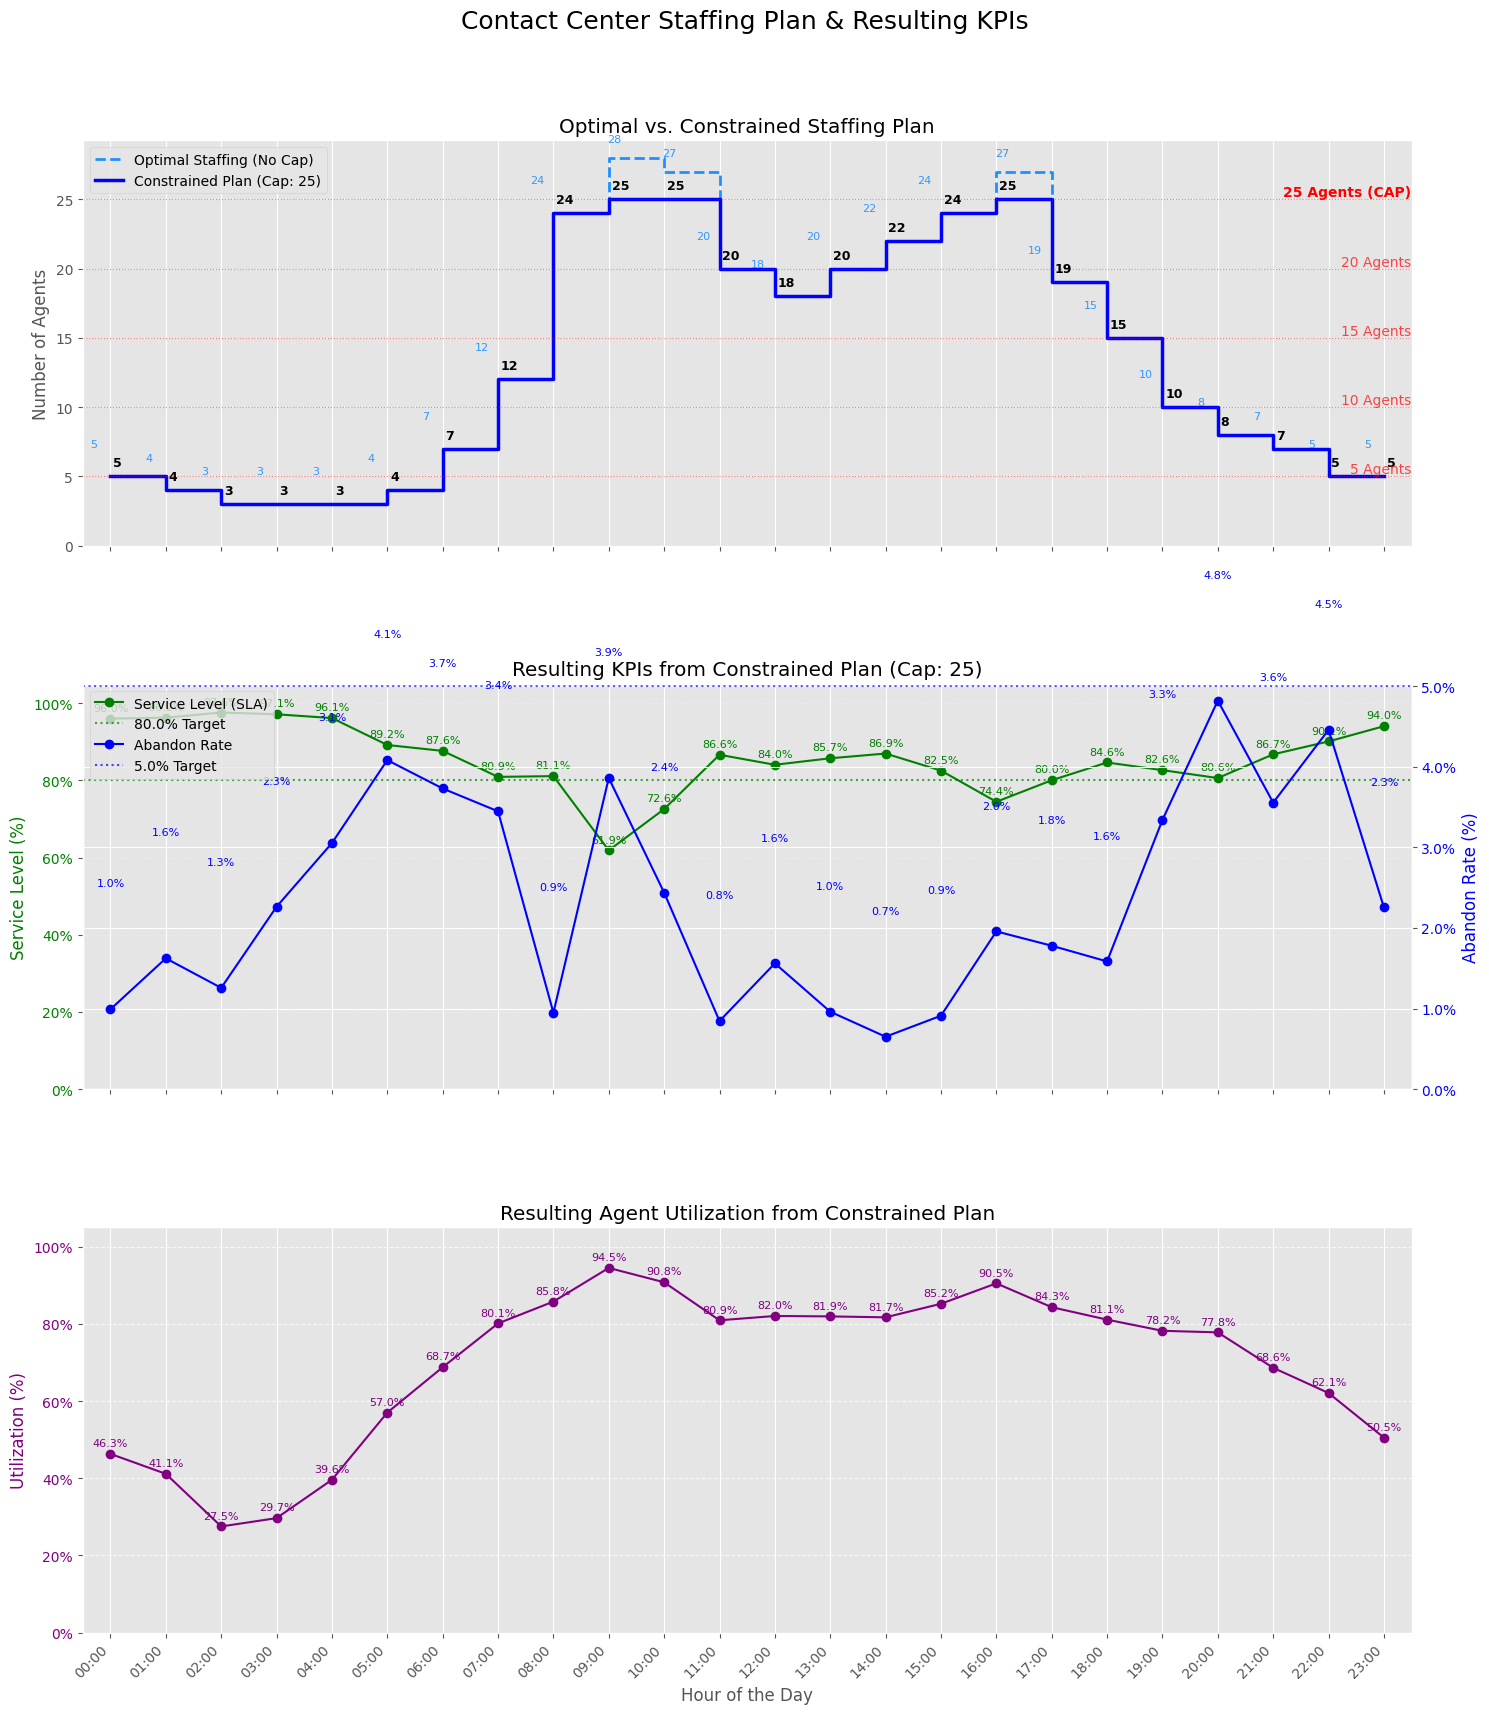

In [55]:
import simpy
import random
import statistics
import numpy as np
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- 1. Simulation Parameters ---

NUM_REPLICATIONS_PER_HOUR = 100
PATIENCE_SECONDS = 120
SLA_THRESHOLD = 20
SIM_DURATION_PER_HOUR = 3600

# Set the hard limit for agents
AGENT_CAP = 25
MIN_AGENTS_TO_TEST = 1
# Max to search for *optimal* (must be > cap to see the difference)
MAX_AGENTS_TO_TEST = 30 


# --- 2. Call Arrival & Duration Models ---
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0
AVG_CALL_DURATION = 300

# --- 3. Data Structures ---
Call = namedtuple("Call", ["call_id", "arrival_time", "call_duration"])
class Agent:
    def __init__(self, agent_id):
        self.agent_id = agent_id
        self.total_handle_time = 0.0

# --- 4. KPI Collector Class (MODIFIED) ---
class KPIs:
    def __init__(self, agent_list):
        self.total_arrivals = 0
        self.total_answered = 0
        self.total_abandoned = 0
        self.wait_times = []
        self.sla_met_count = 0
        self.total_handle_time = 0.0
        self.agent_list = agent_list

    def calculate_results(self, total_sim_time):
        results = {}
        if self.total_arrivals > 0:
            results['abandon_rate'] = (self.total_abandoned / self.total_arrivals) * 100
        else:
            results['abandon_rate'] = 0.0

        if self.total_answered > 0:
            results['asa'] = statistics.mean(self.wait_times)
            results['sla'] = (self.sla_met_count / self.total_answered) * 100
        else:
            results['asa'] = np.nan
            results['sla'] = np.nan
        
        # --- Add Utilization Calculation ---
        if total_sim_time > 0 and len(self.agent_list) > 0:
            total_agent_seconds_available = len(self.agent_list) * total_sim_time
            results['utilization'] = (self.total_handle_time / total_agent_seconds_available) * 100
        else:
            results['utilization'] = 0.0
            
        return results

# --- 5. Distribution Sampling Functions (Unchanged) ---
def sample_interarrival_time(rate_lambda):
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration():
    rate_lambda = 1.0 / AVG_CALL_DURATION
    return random.expovariate(rate_lambda)

# --- 6. Pre-Generation Function (Unchanged) ---
def pre_generate_calls(sim_duration, rate_lambda):
    call_list = []
    call_id_counter = 0
    current_time = 0.0
    while current_time < sim_duration:
        time_to_next_call = sample_interarrival_time(rate_lambda)
        arrival_time = current_time + time_to_next_call
        if arrival_time > sim_duration: break
        call_duration = sample_call_duration()
        call_id_counter += 1
        call_list.append(
            Call(call_id=call_id_counter,
                 arrival_time=arrival_time,
                 call_duration=call_duration)
        )
        current_time = arrival_time
    return call_list

# --- 7. The "Call" Process (MODIFIED) ---
def call_process(env, call, agent_store, kpis):
    arrival_time = env.now
    call_duration = call.call_duration
    get_agent_request = agent_store.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)
    
    result = yield get_agent_request | patience_timeout
    if get_agent_request in result:
        agent = get_agent_request.value 
        wait_time = env.now - arrival_time
        kpis.total_answered += 1
        kpis.wait_times.append(wait_time)
        if wait_time <= SLA_THRESHOLD: kpis.sla_met_count += 1
        
        # --- THIS IS THE FIX ---
        # Both total and individual agent handle time must be tracked
        kpis.total_handle_time += call_duration # <-- THIS LINE WAS ADDED
        agent.total_handle_time += call_duration 
        # ---------------------
        
        yield env.timeout(call_duration)
        yield agent_store.put(agent)
    else:
        kpis.total_abandoned += 1
        get_agent_request.cancel()

# --- 8. The "Call Generator" Process (Unchanged) ---
def call_generator(env, agent_store, kpis, call_list):
    for call in call_list:
        time_to_wait = call.arrival_time - env.now
        if time_to_wait > 0: yield env.timeout(time_to_wait)
        kpis.total_arrivals += 1
        env.process(call_process(env, call, agent_store, kpis))

# --- 9. Single Simulation Run Function (Unchanged) ---
def run_one_simulation_replica(num_agents, sim_duration, rate_lambda):
    call_trace = pre_generate_calls(sim_duration, rate_lambda)
    agent_objects = [Agent(f"Agent-{j+1}") for j in range(num_agents)]
    kpis = KPIs(agent_list=agent_objects)
    env = simpy.Environment()
    agent_pool = simpy.Store(env)
    agent_pool.items = agent_objects[:]
    
    env.process(call_generator(env, agent_pool, kpis, call_trace))
    env.run(until=sim_duration)
    
    return kpis.calculate_results(sim_duration)

# --- 10. Helper Function for Binary Search (MODIFIED) ---
def check_kpis_for_n_agents(hour, n_agents, rate_for_hour, sla_target, abandon_target):
    """
    Runs all replications for a single N and returns:
    (is_feasible, mean_sla, mean_abandon_rate, mean_utilization)
    """
    replication_kpis = []
    for i in range(NUM_REPLICATIONS_PER_HOUR):
        random.seed(i + hour*1000 + n_agents*100) # Unique seed
        kpis = run_one_simulation_replica(
            num_agents=n_agents,
            sim_duration=SIM_DURATION_PER_HOUR,
            rate_lambda=rate_for_hour
        )
        replication_kpis.append(kpis)

    mean_sla = np.nanmean([r['sla'] for r in replication_kpis])
    mean_abandon = np.nanmean([r['abandon_rate'] for r in replication_kpis])
    mean_util = np.nanmean([r['utilization'] for r in replication_kpis]) # Get utilization

    is_feasible = (mean_sla >= sla_target and mean_abandon <= abandon_target)
        
    return is_feasible, mean_sla, mean_abandon, mean_util # Return it

# --- 11. MODIFIED: Optimization Function with Agent Cap ---
def find_hourly_staffing(sla_target=80.0, abandon_target=5.0):
    """
    Finds the optimal and constrained agents per hour, respecting the AGENT_CAP.
    """
    print("--- Starting Hourly Staffing Optimization (Binary Search) ---")
    print(f"AGENT CAP: Max {AGENT_CAP} agents allowed per hour.")
    
    staffing_results = []
    
    for hour in range(24):
        rate_for_hour = HOURLY_RATES_PER_SEC.get(hour, DEFAULT_RATE_PER_SEC)
        
        if rate_for_hour <= 0:
            print(f"Hour {hour:02d}: No calls. Agents required: 0")
            staffing_results.append({
                'hour': hour, 'optimal_n': 0, 'constrained_n': 0,
                'sla': 100.0, 'abandon_rate': 0.0, 'utilization': 0.0
            })
            continue

        print(f"\n--- Testing Hour {hour:02d} (Rate: {rate_for_hour*3600:.1f} calls/hr) ---")
        
        low = MIN_AGENTS_TO_TEST
        high = MAX_AGENTS_TO_TEST
        optimal_n_found = np.nan
        
        run_results_cache = {}

        while low <= high:
            mid_n = (low + high) // 2
            is_feasible, sla, abandon, util = check_kpis_for_n_agents(
                hour, mid_n, rate_for_hour, sla_target, abandon_target
            )
            run_results_cache[mid_n] = (sla, abandon, util) # Cache utilization
            
            if is_feasible:
                optimal_n_found = mid_n
                high = mid_n - 1
            else:
                low = mid_n + 1
        
        final_optimal_n = optimal_n_found
        constrained_n = np.nan
        final_sla = np.nan
        final_abandon = np.nan
        final_util = np.nan # Add util variable
        
        if pd.isna(optimal_n_found) or optimal_n_found > AGENT_CAP:
            constrained_n = AGENT_CAP
            if pd.isna(optimal_n_found):
                 print(f"  WARNING: No solution found within {MAX_AGENTS_TO_TEST} agents. Capping at {AGENT_CAP}.")
            else:
                 print(f"  -> Optimal N ({int(optimal_n_found)}) is above cap. Capping at {AGENT_CAP}.")
        else:
            constrained_n = optimal_n_found
            print(f"  -> Optimal N for Hour {hour:02d} is {int(constrained_n)}")

        if constrained_n in run_results_cache:
            final_sla, final_abandon, final_util = run_results_cache[constrained_n] # Get util from cache
        else:
            print(f"  (Running one more check for constrained N={constrained_n})")
            is_feasible, sla, abandon, util = check_kpis_for_n_agents(
                hour, int(constrained_n), rate_for_hour, sla_target, abandon_target
            )
            final_sla, final_abandon, final_util = sla, abandon, util # Store util
            
        staffing_results.append({
             'hour': hour, 
             'optimal_n': final_optimal_n,
             'constrained_n': constrained_n,
             'sla': final_sla, 
             'abandon_rate': final_abandon,
             'utilization': final_util # Add to results
         })
            
    print("\n--- Optimization Complete ---")
    return pd.DataFrame(staffing_results).set_index('hour')

# --- 12. MODIFIED: Dashboard Plotting Function ---
def plot_dashboard(df, sla_target=80.0, abandon_target=5.0):
    """
    Creates a 3-panel dashboard plot:
    1. Optimal vs. Constrained staffing.
    2. Resulting KPIs (SLA and Abandon).
    3. Resulting Agent Utilization.
    """
    print("Generating optimization dashboard plot...")
    
    fig, (ax_agents, ax_kpis, ax_util) = plt.subplots(
        nrows=3, # Changed to 3 rows
        ncols=1, 
        figsize=(15, 18), # Increased height
        sharex=True,
        gridspec_kw={'height_ratios': [1, 1, 1]} # 3 equal panels
    )
    fig.suptitle('Contact Center Staffing Plan & Resulting KPIs', fontsize=18)
    
    # --- Top Panel: Agent Staffing Plan ---
    
    hours = df.index.values
    
    # Plot Optimal (Unconstrained) Plan
    ax_agents.step(hours, df['optimal_n'], where='post', color='dodgerblue', 
                   linestyle='--', linewidth=2, label='Optimal Staffing (No Cap)')
    
    # Plot Constrained (Capped) Plan
    ax_agents.step(hours, df['constrained_n'], where='post', color='blue', 
                   linestyle='-', linewidth=2.5, label=f'Constrained Plan (Cap: {AGENT_CAP})')
    
    # Add text labels for the *optimal* plan
    for h, n_optimal in zip(hours, df['optimal_n']):
        if not pd.isna(n_optimal) and n_optimal > 0:
            offset_y = 1.0
            offset_x = -0.1
            n_constrained = df.loc[h, 'constrained_n']
            if not pd.isna(n_constrained) and n_optimal == n_constrained:
                offset_y += 1.0 
                offset_x = -0.3
            elif not pd.isna(n_constrained) and n_optimal > n_constrained:
                offset_x = 0.1
            
            ax_agents.text(h + offset_x, n_optimal + offset_y, f'{int(n_optimal)}', 
                           verticalalignment='bottom', horizontalalignment='center',
                           color='dodgerblue', fontsize=8, alpha=0.9)
    
    # Add text labels for the *constrained* plan
    for h, n_constrained in zip(hours, df['constrained_n']):
        if not pd.isna(n_constrained) and n_constrained > 0:
            ax_agents.text(h + 0.05, n_constrained + 0.5, f'{int(n_constrained)}', 
                           verticalalignment='bottom', horizontalalignment='left',
                           color='black', fontsize=9, fontweight='bold')
    
    # Add horizontal reference lines
    for n in [5, 10, 15, 20, 25]:
        ax_agents.axhline(y=n, color='red', linestyle=':', alpha=0.5, linewidth=0.8)
        if n == AGENT_CAP:
             ax_agents.text(23.5, n, f'{n} Agents (CAP)', color='red', 
                           horizontalalignment='right', verticalalignment='bottom',
                           fontweight='bold')
        else:
             ax_agents.text(23.5, n, f'{n} Agents', color='red', alpha=0.7, 
                           horizontalalignment='right', verticalalignment='bottom')

    ax_agents.set_title('Optimal vs. Constrained Staffing Plan')
    ax_agents.set_ylabel('Number of Agents')
    ax_agents.grid(axis='y', linestyle='--', alpha=0.7)
    ax_agents.set_ylim(bottom=0)
    ax_agents.legend(loc='upper left')

    # --- Middle Panel: Resulting KPIs (SLA & Abandon) ---
    
    ax_abandon = ax_kpis.twinx()

    # Plot SLA
    ax_kpis.plot(df.index, df['sla'], color='green', marker='o', linestyle='-', label='Service Level (SLA)')
    ax_kpis.axhline(y=sla_target, color='green', linestyle=':', alpha=0.7, label=f'{sla_target}% Target')
    ax_kpis.set_ylabel('Service Level (%)', color='green')
    ax_kpis.tick_params(axis='y', labelcolor='green')
    ax_kpis.set_ylim(0, 105)
    
    # Plot Abandon Rate
    ax_abandon.plot(df.index, df['abandon_rate'], color='blue', marker='o', linestyle='-', label='Abandon Rate')
    ax_abandon.axhline(y=abandon_target, color='blue', linestyle=':', alpha=0.7, label=f'{abandon_target}% Target')
    ax_abandon.set_ylabel('Abandon Rate (%)', color='blue')
    ax_abandon.tick_params(axis='y', labelcolor='blue')
    ax_abandon.set_ylim(bottom=0)

    # Add text labels to KPI points
    for h, sla_val, abandon_val in zip(hours, df['sla'], df['abandon_rate']):
        if not pd.isna(sla_val):
            ax_kpis.text(h, sla_val + 1.5, f'{sla_val:.1f}%', 
                         verticalalignment='bottom', horizontalalignment='center',
                         color='green', fontsize=8)
        if not pd.isna(abandon_val):
            ax_abandon.text(h, abandon_val + 1.5, f'{abandon_val:.1f}%', 
                            verticalalignment='bottom', horizontalalignment='center',
                            color='blue', fontsize=8)

    ax_kpis.set_title(f'Resulting KPIs from Constrained Plan (Cap: {AGENT_CAP})')
    ax_kpis.grid(axis='y', linestyle='--', alpha=0.2)
    
    # Format Y-axes as percentages
    ax_kpis.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_abandon.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    lines_sla, labels_sla = ax_kpis.get_legend_handles_labels()
    lines_abandon, labels_abandon = ax_abandon.get_legend_handles_labels()
    ax_abandon.legend(lines_sla + lines_abandon, labels_sla + labels_abandon, loc='upper left')

    # --- NEW: Bottom Panel: Agent Utilization ---
    
    ax_util.plot(df.index, df['utilization'], color='purple', marker='o', linestyle='-')
    ax_util.set_title('Resulting Agent Utilization from Constrained Plan')
    ax_util.set_ylabel('Utilization (%)', color='purple')
    ax_util.tick_params(axis='y', labelcolor='purple')
    ax_util.set_ylim(0, 105)
    ax_util.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add text labels for utilization points
    for h, util_val in zip(hours, df['utilization']):
        if not pd.isna(util_val):
            ax_util.text(h, util_val + 1.5, f'{util_val:.1f}%', 
                         verticalalignment='bottom', horizontalalignment='center',
                         color='purple', fontsize=8)
    
    # Format Y-axis as percentage
    ax_util.yaxis.set_major_formatter(mtick.PercentFormatter())

    # Format shared X-axis (only on the bottom-most plot)
    ax_util.set_xlabel('Hour of the Day')
    ax_util.set_xticks(np.arange(0, 24, 1))
    ax_util.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha='right')
    ax_util.set_xlim(-0.5, 23.5)

    # --- Finalize Layout ---
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('hourly_staffing_dashboard_with_utilization.png')
    print("Dashboard plot saved to 'hourly_staffing_dashboard_with_utilization.png'")


# --- 13. Main Execution (Unchanged) ---
if __name__ == "__main__":
    random.seed(42)
    
    staffing_df = find_hourly_staffing()
    
    print("\n--- Final Staffing Plan (with resulting KPIs) ---")
    print(staffing_df)
    
    plot_dashboard(staffing_df)

In [56]:
staffing_df

,optimal_n,constrained_n,sla,abandon_rate,utilization
hour,,,,,
0,5,5,95.987081,0.991149,46.300878
1,4,4,96.226764,1.623804,41.135369
2,3,3,97.562701,1.256889,27.503286
3,3,3,97.107064,2.263887,29.661987
4,3,3,96.126152,3.054065,39.594739
5,4,4,89.152225,4.083767,56.996317
6,7,7,87.623800,3.731461,68.749069
7,12,12,80.894437,3.448116,80.097841
8,24,24,81.086478,0.948050,85.753021



--- Converted Dictionary ---
{0: 5, 1: 4, 2: 3, 3: 3, 4: 3, 5: 4, 6: 7, 7: 12, 8: 24, 9: 25, 10: 25, 11: 20, 12: 18, 13: 20, 14: 22, 15: 24, 16: 25, 17: 19, 18: 15, 19: 10, 20: 8, 21: 7, 22: 5, 23: 5}
Starting 25-hour continuous simulation...
Evaluating staffing plan with 20 agent cap.
...Continuous simulation complete.
Calculating final KPIs from continuous simulation...

--- Actual Hourly Performance (Hours 0-23) ---
             sla  abandon_rate  utilization  agents_scheduled  total_calls
hour                                                                      
0      85.714286      0.000000    77.205591                 5           42
1      87.500000      0.000000    40.453696                 4           16
2     100.000000      0.000000    23.820123                 3            9
3     100.000000      0.000000    29.817296                 3           12
4      77.777778      0.000000    50.190047                 3           18
5      85.714286     19.230769    66.837784        

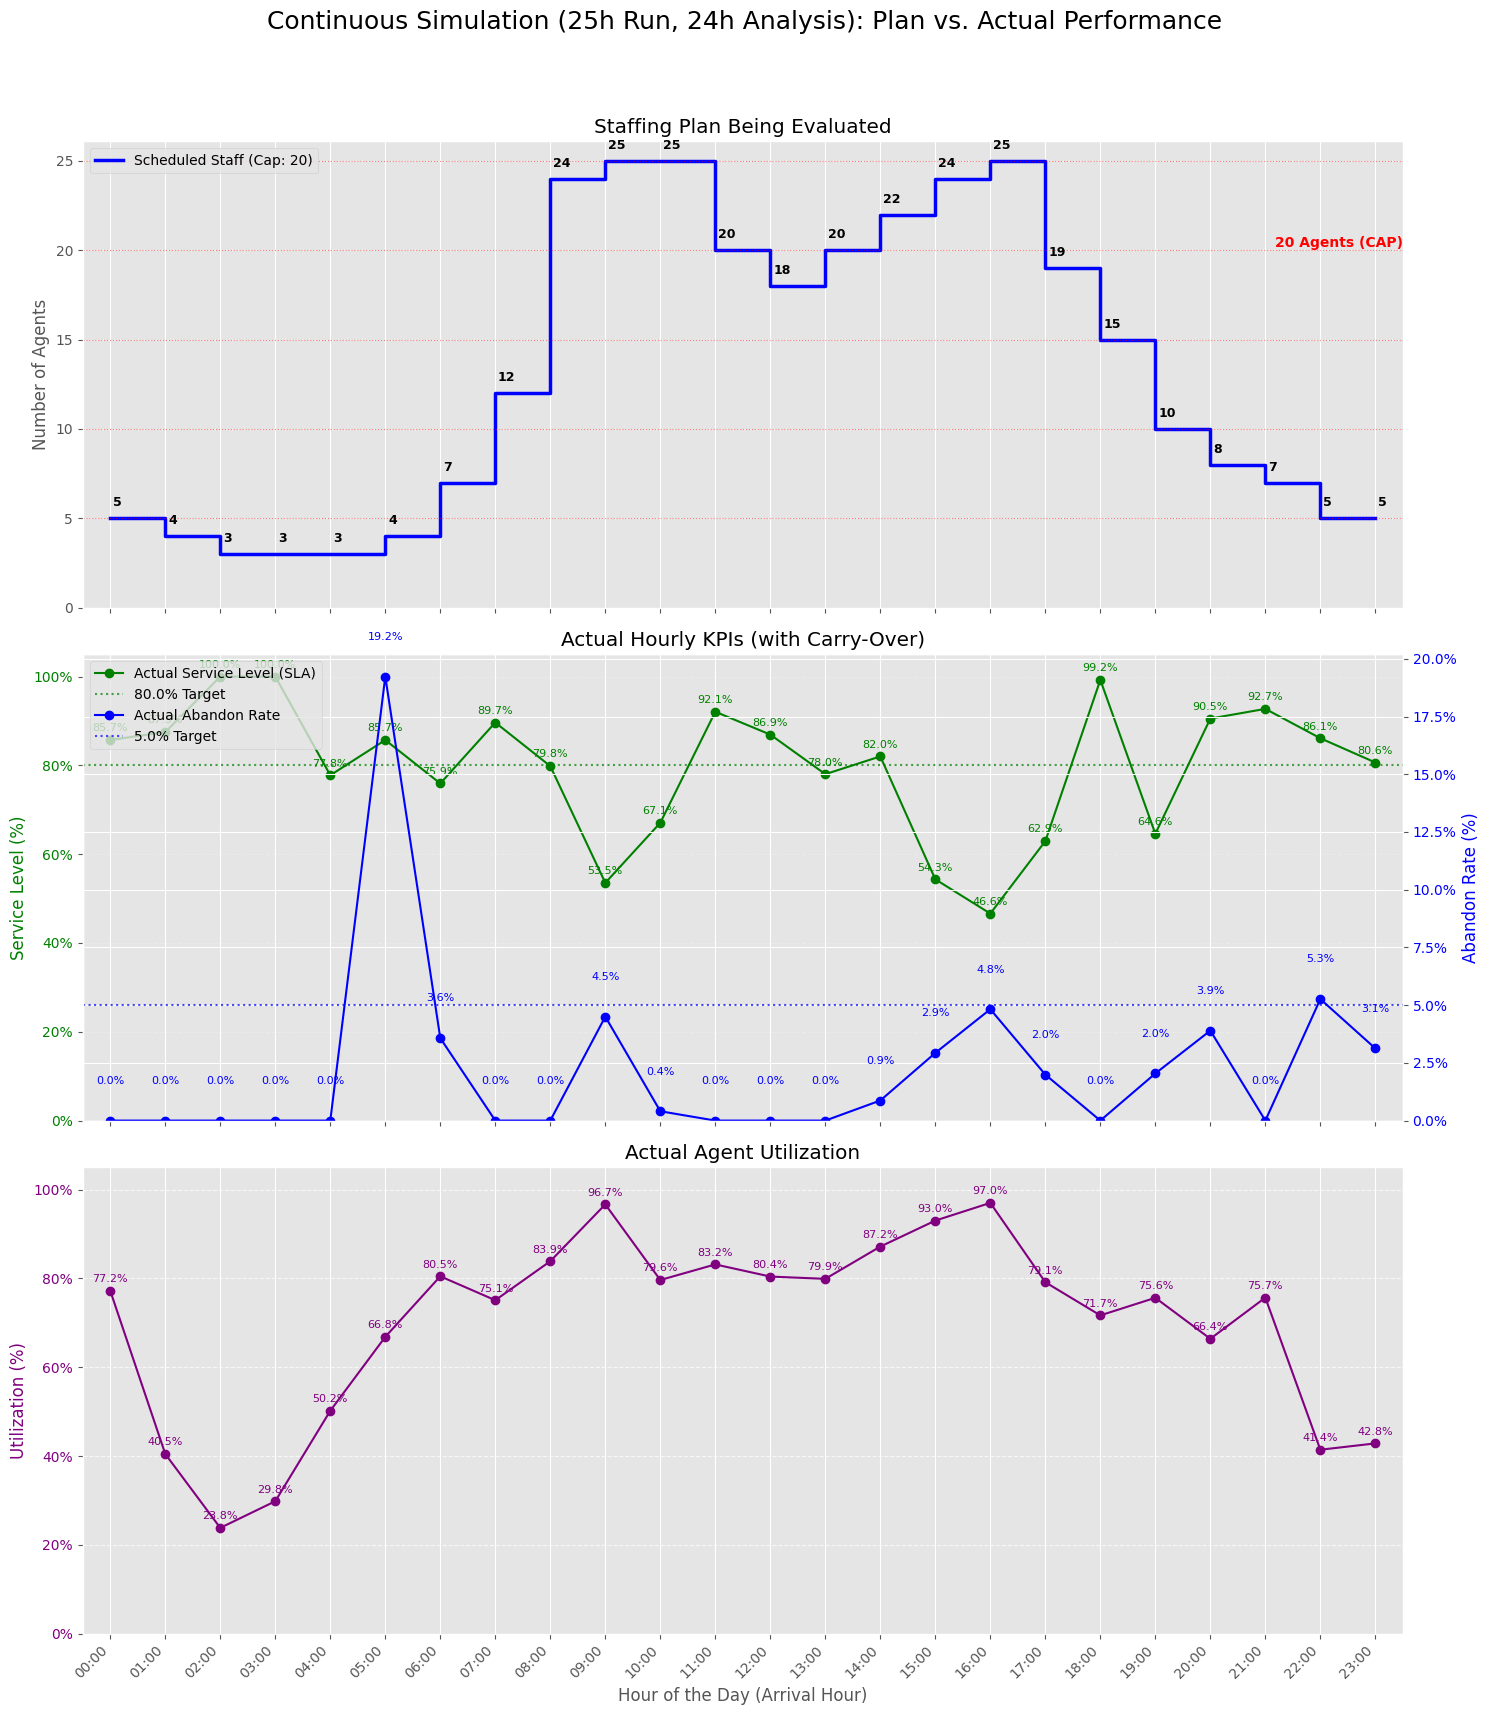

In [57]:
import simpy
import random
import statistics
import numpy as np
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- 1. Simulation Parameters (MODIFIED) ---
PATIENCE_SECONDS = 120
SLA_THRESHOLD = 20
SIM_DURATION_HOURS = 25 # <-- Run for 25 hours
SIM_DURATION_SEC = SIM_DURATION_HOURS * 3600
RANDOM_SEED = 42
AGENT_CAP = 20 # Note: The plan below is based on the 20-agent cap

# --- 2. Call Arrival & Duration Models (Time-Varying) ---
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0
AVG_CALL_DURATION = 300

# --- 3. INPUT: Staffing Plan to Evaluate (MODIFIED) ---
# This plan was generated by the *optimizer* script.
# Select the 'constrained_n' column and convert it to a dictionary
STAFFING_PLAN_TO_EVALUATE = staffing_df['constrained_n'].to_dict()

print("\n--- Converted Dictionary ---")
print(STAFFING_PLAN_TO_EVALUATE)
# --- 4. Data Structures ---
class Agent:
    def __init__(self, agent_id):
        self.agent_id = agent_id

CallResult = namedtuple("CallResult", [
    "call_id", 
    "arrival_hour", 
    "status", 
    "wait_time", 
    "handle_time"
])

# --- 5. Distribution Sampling Functions ---
def sample_interarrival_time(current_time_seconds):
    """Samples inter-arrival time based on the time of day."""
    current_hour = int(current_time_seconds // 3600) % 24 # <-- Wraps around
    rate_lambda = HOURLY_RATES_PER_SEC.get(current_hour, DEFAULT_RATE_PER_SEC)
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration():
    """Samples the duration of a call (service time)."""
    rate_lambda = 1.0 / AVG_CALL_DURATION
    return random.expovariate(rate_lambda)

# --- 6. The "Call" Process (MODIFIED) ---
def call_process(env, call_id, agent_pool, results_log_list):
    """
    Life cycle of a single call.
    Logs its final result to the shared 'results_log_list'.
    """
    arrival_time = env.now
    arrival_hour = int(arrival_time // 3600) # <-- No modulo here
    
    get_agent_request = agent_pool.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)
    
    result = yield get_agent_request | patience_timeout
    
    if get_agent_request in result:
        # --- Call Answered ---
        agent = get_agent_request.value 
        wait_time = env.now - arrival_time
        handle_time = sample_call_duration()
        
        results_log_list.append(CallResult(
            call_id=call_id,
            arrival_hour=arrival_hour,
            status='ANSWERED',
            wait_time=wait_time,
            handle_time=handle_time
        ))
        
        yield env.timeout(handle_time)
        yield agent_pool.put(agent)
    else:
        # --- Call Abandoned ---
        get_agent_request.cancel()
        
        results_log_list.append(CallResult(
            call_id=call_id,
            arrival_hour=arrival_hour,
            status='ABANDONED',
            wait_time=PATIENCE_SECONDS,
            handle_time=0
        ))

# --- 7. The "Call Generator" Process (MODIFIED) ---
def call_generator(env, agent_pool, results_log_list):
    """Generates calls continuously for the full simulation duration."""
    call_id_counter = 0
    while env.now < SIM_DURATION_SEC:
        # Get inter-arrival time based on *current* sim time
        interarrival = sample_interarrival_time(env.now)
        yield env.timeout(interarrival)
        
        # Stop if the simulation time has been reached *during* the wait
        if env.now >= SIM_DURATION_SEC:
            break
            
        call_id_counter += 1
        env.process(call_process(env, call_id_counter, agent_pool, results_log_list))

# --- 8. The "Staffing Manager" Process (MODIFIED) ---
def staffing_manager(env, agent_pool, staffing_plan, master_agent_list):
    """
    Adds or removes agents on the hour for the full duration (e.g., 25 hours).
    """
    for hour in range(SIM_DURATION_HOURS):
        # Use (hour % 24) to get the plan for the 25th hour (uses Hour 0's plan)
        n_required = staffing_plan.get(hour % 24, 0)
        n_current = len(master_agent_list)
        delta = n_required - n_current
        
        if delta > 0:
            # --- SCALE UP ---
            # print(f"[{env.now/3600:.1f}h] Staffing UP: Adding {delta} agents (Total: {n_required})")
            for i in range(delta):
                agent = Agent(f"Agent-{hour}-{i}")
                master_agent_list.append(agent)
                yield agent_pool.put(agent)
                
        elif delta < 0:
            # --- SCALE DOWN ---
            # print(f"[{env.now/3600:.1f}h] Staffing DOWN: Removing {abs(delta)} agents (Total: {n_required})")
            for _ in range(abs(delta)):
                env.process(remove_agent_process(env, agent_pool, master_agent_list))
                
        # Wait until the next hour
        yield env.timeout(3600)

def remove_agent_process(env, agent_pool, master_agent_list):
    """Waits for an agent to be free, then removes them."""
    agent = yield agent_pool.get()
    master_agent_list.remove(agent)
    # print(f"[{env.now/3600:.1f}h] An agent has finished shift and left.")

# --- 9. Post-Simulation Analysis Function (MODIFIED) ---
def calculate_final_kpis(results_log_list, staffing_plan):
    """
    Analyzes the raw call log and calculates hourly KPIs.
    It now only analyzes hours 0-23.
    """
    print("Calculating final KPIs from continuous simulation...")
    df = pd.DataFrame(results_log_list)
    
    if df.empty:
        print("No calls were logged.")
        return pd.DataFrame()

    hourly_stats = []
    
    # --- Only analyze the first 24 hours (0-23) ---
    for hour in range(24):
        # We only care about calls that *arrived* in this hour
        df_hour = df[df['arrival_hour'] == hour]
        
        total_calls = len(df_hour)
        answered = (df_hour['status'] == 'ANSWERED').sum()
        abandoned = (df_hour['status'] == 'ABANDONED').sum()
        
        if answered > 0:
            sla_met = (df_hour[df_hour['status'] == 'ANSWERED']['wait_time'] <= SLA_THRESHOLD).sum()
            sla = (sla_met / answered) * 100
        else:
            sla = np.nan
            
        if total_calls > 0:
            abandon_rate = (abandoned / total_calls) * 100
        else:
            abandon_rate = 0.0
            
        # Calculate Utilization
        agents_this_hour = staffing_plan.get(hour, 0)
        if agents_this_hour > 0:
            # We must account for handle time from calls *last* hour
            # that carried over *into* this hour. This is complex.
            # A good proxy is handle time of calls *arriving* this hour.
            total_handle_time_this_hour = df_hour['handle_time'].sum()
            total_seconds_available = agents_this_hour * 3600
            utilization = (total_handle_time_this_hour / total_seconds_available) * 100
        else:
            utilization = 0.0
            
        hourly_stats.append({
            'hour': hour,
            'sla': sla,
            'abandon_rate': abandon_rate,
            'utilization': utilization,
            'agents_scheduled': agents_this_hour,
            'total_calls': total_calls
        })
        
    return pd.DataFrame(hourly_stats).set_index('hour')

# --- 10. Dashboard Plotting Function (MODIFIED) ---
def plot_evaluation_dashboard(df, sla_target=80.0, abandon_target=5.0):
    """
    Creates a 3-panel plot of the *actual* performance of the plan
    for hours 0-23.
    """
    print("Generating evaluation dashboard plot...")
    
    # Ensure we only plot 0-23
    df_plot = df.loc[0:23]
    
    fig, (ax_agents, ax_kpis, ax_util) = plt.subplots(
        nrows=3, ncols=1, figsize=(15, 18), 
        sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]}
    )
    fig.suptitle('Continuous Simulation (25h Run, 24h Analysis): Plan vs. Actual Performance', fontsize=18)
    
    hours = df_plot.index.values

    # --- Top Panel: The Staffing Plan We Tested ---
    ax_agents.step(hours, df_plot['agents_scheduled'], where='post', color='blue', 
                   linestyle='-', linewidth=2.5, label=f'Scheduled Staff (Cap: {AGENT_CAP})')
    
    for h, n in zip(hours, df_plot['agents_scheduled']):
        if not pd.isna(n) and n > 0:
            ax_agents.text(h + 0.05, n + 0.5, f'{int(n)}', 
                           verticalalignment='bottom', horizontalalignment='left',
                           color='black', fontsize=9, fontweight='bold')
    
    for n in [5, 10, 15, 20, 25]:
        ax_agents.axhline(y=n, color='red', linestyle=':', alpha=0.5, linewidth=0.8)
        if n == AGENT_CAP:
             ax_agents.text(23.5, n, f'{n} Agents (CAP)', color='red', 
                           horizontalalignment='right', verticalalignment='bottom',
                           fontweight='bold')

    ax_agents.set_title('Staffing Plan Being Evaluated')
    ax_agents.set_ylabel('Number of Agents')
    ax_agents.grid(axis='y', linestyle='--', alpha=0.7)
    ax_agents.set_ylim(bottom=0)
    ax_agents.legend(loc='upper left')
    ax_agents.set_xlim(-0.5, 23.5) # Explicitly set x-limit

    # --- Middle Panel: Actual Resulting KPIs ---
    ax_abandon = ax_kpis.twinx()

    ax_kpis.plot(df_plot.index, df_plot['sla'], color='green', marker='o', linestyle='-', label='Actual Service Level (SLA)')
    ax_kpis.axhline(y=sla_target, color='green', linestyle=':', alpha=0.7, label=f'{sla_target}% Target')
    ax_kpis.set_ylabel('Service Level (%)', color='green')
    ax_kpis.tick_params(axis='y', labelcolor='green')
    ax_kpis.set_ylim(0, 105)
    
    ax_abandon.plot(df_plot.index, df_plot['abandon_rate'], color='blue', marker='o', linestyle='-', label='Actual Abandon Rate')
    ax_abandon.axhline(y=abandon_target, color='blue', linestyle=':', alpha=0.7, label=f'{abandon_target}% Target')
    ax_abandon.set_ylabel('Abandon Rate (%)', color='blue')
    ax_abandon.tick_params(axis='y', labelcolor='blue')
    ax_abandon.set_ylim(bottom=0)

    for h, sla_val, abandon_val in zip(hours, df_plot['sla'], df_plot['abandon_rate']):
        if not pd.isna(sla_val):
            ax_kpis.text(h, sla_val + 1.5, f'{sla_val:.1f}%', va='bottom', ha='center', color='green', fontsize=8)
        if not pd.isna(abandon_val):
            ax_abandon.text(h, abandon_val + 1.5, f'{abandon_val:.1f}%', va='bottom', ha='center', color='blue', fontsize=8)

    ax_kpis.set_title('Actual Hourly KPIs (with Carry-Over)')
    ax_kpis.grid(axis='y', linestyle='--', alpha=0.2)
    ax_kpis.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_abandon.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    lines_sla, labels_sla = ax_kpis.get_legend_handles_labels()
    lines_abandon, labels_abandon = ax_abandon.get_legend_handles_labels()
    ax_abandon.legend(lines_sla + lines_abandon, labels_sla + labels_abandon, loc='upper left')

    # --- Bottom Panel: Actual Agent Utilization ---
    ax_util.plot(df_plot.index, df_plot['utilization'], color='purple', marker='o', linestyle='-')
    ax_util.set_title('Actual Agent Utilization')
    ax_util.set_ylabel('Utilization (%)', color='purple')
    ax_util.tick_params(axis='y', labelcolor='purple')
    ax_util.set_ylim(0, 105)
    ax_util.grid(axis='y', linestyle='--', alpha=0.7)
    
    for h, util_val in zip(hours, df_plot['utilization']):
        if not pd.isna(util_val):
            ax_util.text(h, util_val + 1.5, f'{util_val:.1f}%', va='bottom', ha='center', color='purple', fontsize=8)
    
    ax_util.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_util.set_xlabel('Hour of the Day (Arrival Hour)')
    ax_util.set_xticks(np.arange(0, 24, 1))
    ax_util.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha='right')
    ax_util.set_xlim(-0.5, 23.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('continuous_simulation_evaluation_25hr.png')
    print("Dashboard plot saved to 'continuous_simulation_evaluation_25hr.png'")


# --- 11. Main Execution ---
if __name__ == "__main__":
    print(f"Starting 25-hour continuous simulation...")
    print(f"Evaluating staffing plan with {AGENT_CAP} agent cap.")
    random.seed(RANDOM_SEED)
    
    # --- Setup Simulation ---
    results_log_list = []
    master_agent_list = [] 
    
    env = simpy.Environment()
    agent_pool = simpy.Store(env)
    
    # Start the processes
    env.process(staffing_manager(env, agent_pool, STAFFING_PLAN_TO_EVALUATE, master_agent_list))
    env.process(call_generator(env, agent_pool, results_log_list))
    
    # --- Run Simulation ---
    env.run()
    print("...Continuous simulation complete.")
    
    # --- Analyze and Plot Results ---
    results_df = calculate_final_kpis(results_log_list, STAFFING_PLAN_TO_EVALUATE)
    
    print("\n--- Actual Hourly Performance (Hours 0-23) ---")
    print(results_df)
    
    plot_evaluation_dashboard(results_df)

Starting 25-hour continuous simulation...
Evaluating staffing plan: {0: 5, 1: 4, 2: 3, 3: 3, 4: 3, 5: 4, 6: 7, 7: 12, 8: 24, 9: 25, 10: 25, 11: 20, 12: 18, 13: 20, 14: 22, 15: 24, 16: 25, 17: 19, 18: 15, 19: 10, 20: 8, 21: 7, 22: 5, 23: 5}
...Continuous simulation complete.
Calculating final KPIs from continuous simulation...

--- Actual Hourly Performance (Hours 0-23) ---
             sla  abandon_rate  utilization  agents_scheduled  total_calls
hour                                                                      
0      85.714286      0.000000    77.205591                 5           42
1      87.500000      0.000000    40.453696                 4           16
2     100.000000      0.000000    23.820123                 3            9
3     100.000000      0.000000    29.817296                 3           12
4      77.777778      0.000000    50.190047                 3           18
5      85.714286     19.230769    66.837784                 4           26
6      75.925926      3.

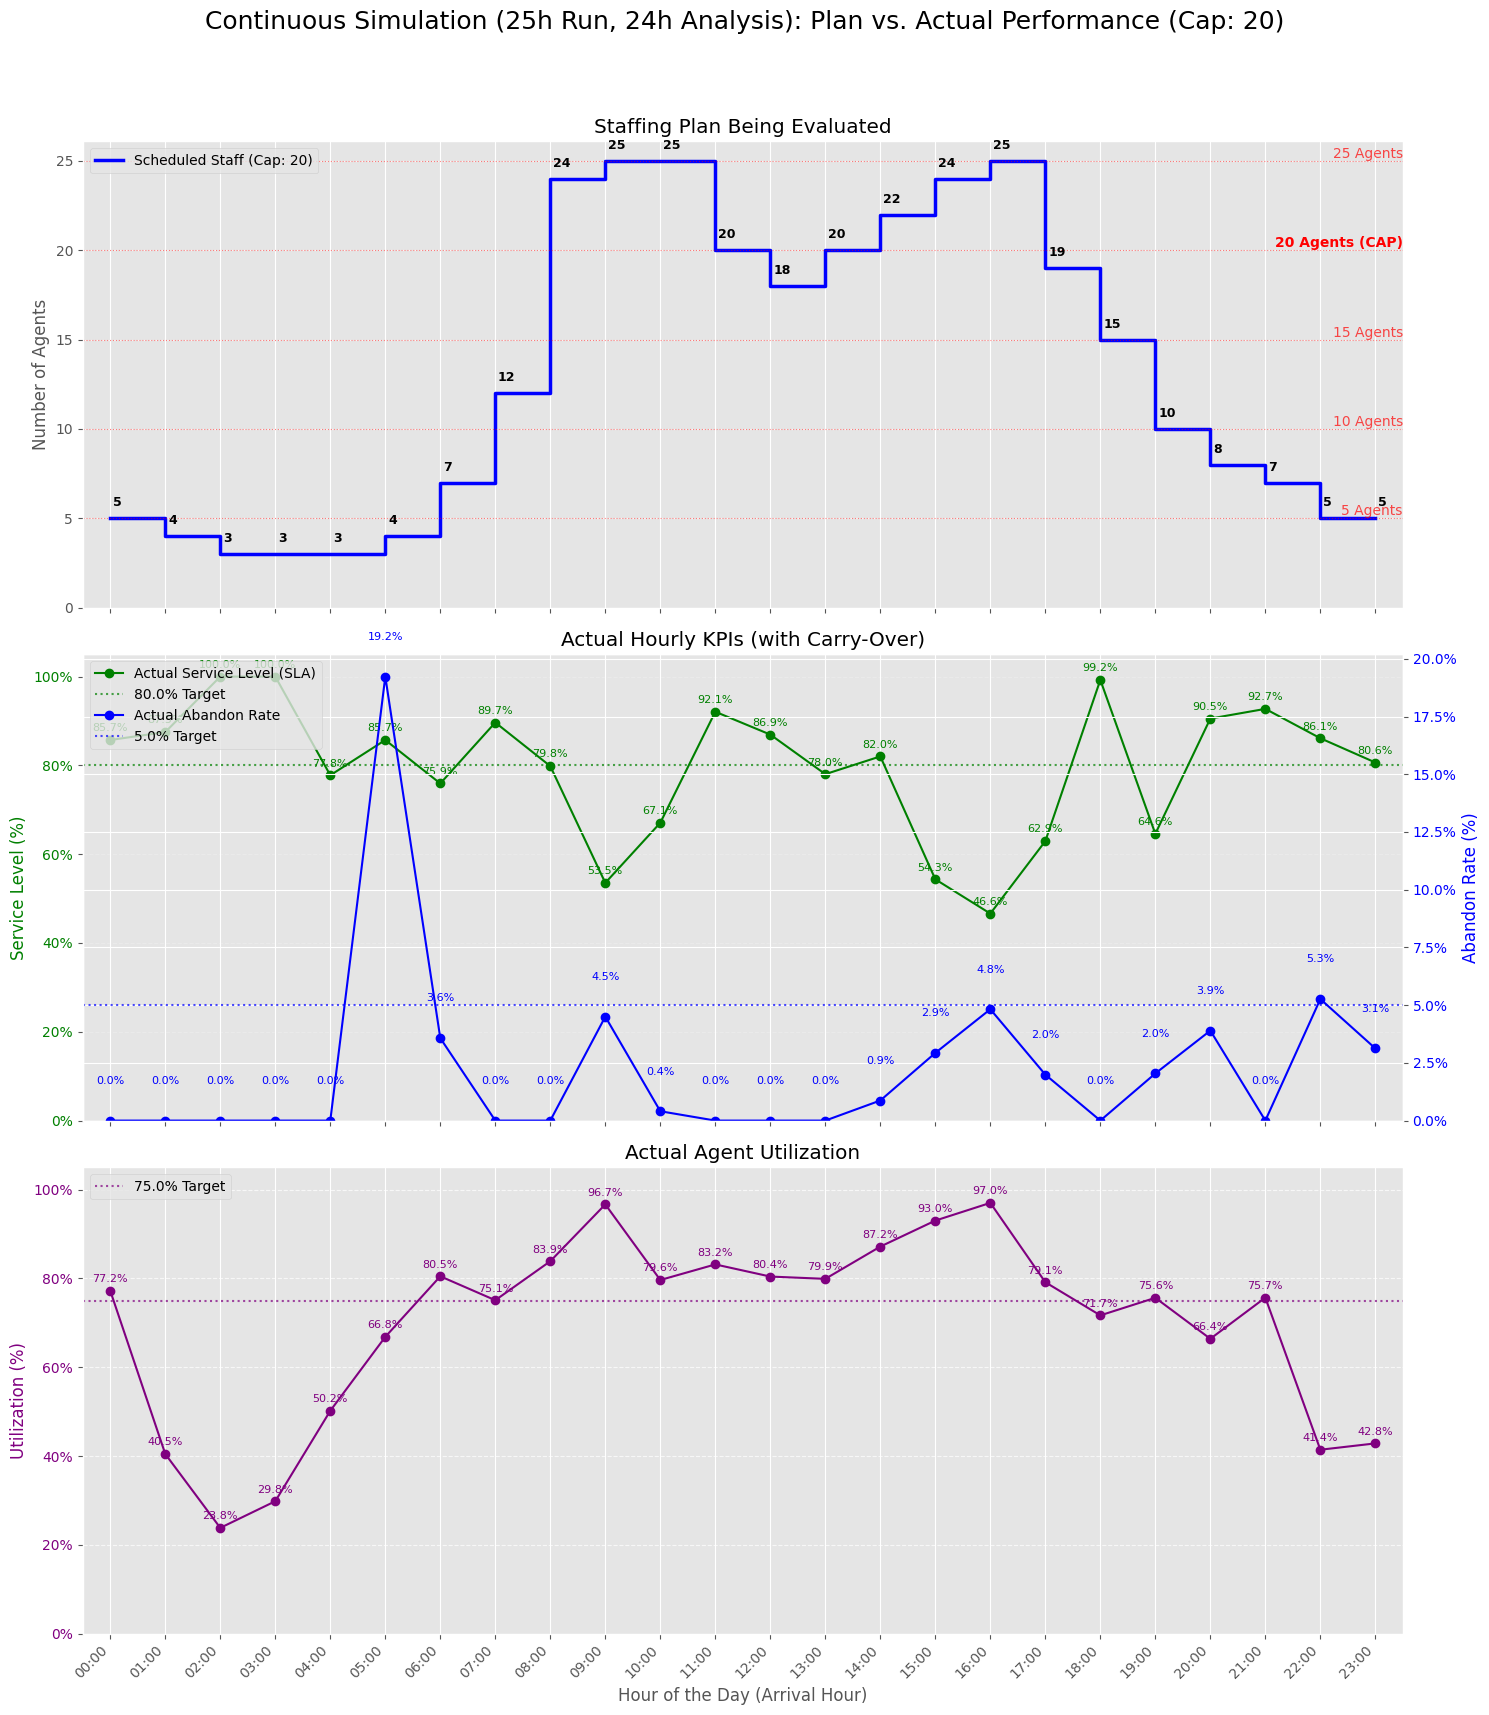

In [58]:
import simpy
import random
import statistics
import numpy as np
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- 1. Simulation Parameters ---
PATIENCE_SECONDS = 120
SLA_THRESHOLD = 20
SIM_DURATION_HOURS = 25 # Run for 25 hours to avoid end-of-run bias
SIM_DURATION_SEC = SIM_DURATION_HOURS * 3600
RANDOM_SEED = 42
AGENT_CAP = 20 # The cap used by the plan we are testing

# --- 2. Call Arrival & Duration Models (Time-Varying) ---
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0
AVG_CALL_DURATION = 300

# --- 3. INPUT: Staffing Plan to Evaluate ---
STAFFING_PLAN_TO_EVALUATE = staffing_df['constrained_n'].to_dict()
# --- 4. Data Structures ---
class Agent:
    def __init__(self, agent_id):
        self.agent_id = agent_id

CallResult = namedtuple("CallResult", [
    "call_id", 
    "arrival_hour", # The hour the call *arrived* (0-24)
    "status", 
    "wait_time", 
    "handle_time"
])

# --- 5. Distribution Sampling Functions ---
def sample_interarrival_time(current_time_seconds):
    """Samples inter-arrival time based on the time of day."""
    current_hour = int(current_time_seconds // 3600) % 24
    rate_lambda = HOURLY_RATES_PER_SEC.get(current_hour, DEFAULT_RATE_PER_SEC)
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration():
    """Samples the duration of a call (service time)."""
    rate_lambda = 1.0 / AVG_CALL_DURATION
    return random.expovariate(rate_lambda)

# --- 6. The "Call" Process ---
def call_process(env, call_id, agent_pool, results_log_list):
    arrival_time = env.now
    arrival_hour = int(arrival_time // 3600)
    
    get_agent_request = agent_pool.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)
    
    result = yield get_agent_request | patience_timeout
    
    if get_agent_request in result:
        agent = get_agent_request.value 
        wait_time = env.now - arrival_time
        handle_time = sample_call_duration()
        
        results_log_list.append(CallResult(
            call_id=call_id,
            arrival_hour=arrival_hour,
            status='ANSWERED',
            wait_time=wait_time,
            handle_time=handle_time
        ))
        
        yield env.timeout(handle_time)
        yield agent_pool.put(agent)
    else:
        get_agent_request.cancel()
        
        results_log_list.append(CallResult(
            call_id=call_id,
            arrival_hour=arrival_hour,
            status='ABANDONED',
            wait_time=PATIENCE_SECONDS,
            handle_time=0
        ))

# --- 7. The "Call Generator" Process ---
def call_generator(env, agent_pool, results_log_list):
    call_id_counter = 0
    while env.now < SIM_DURATION_SEC:
        interarrival = sample_interarrival_time(env.now)
        yield env.timeout(interarrival)
        
        if env.now >= SIM_DURATION_SEC:
            break
            
        call_id_counter += 1
        env.process(call_process(env, call_id_counter, agent_pool, results_log_list))

# --- 8. The "Staffing Manager" Process ---
def staffing_manager(env, agent_pool, staffing_plan, master_agent_list):
    for hour in range(SIM_DURATION_HOURS):
        n_required = staffing_plan.get(hour % 24, 0)
        n_current = len(master_agent_list)
        delta = n_required - n_current
        
        if delta > 0:
            for i in range(delta):
                agent = Agent(f"Agent-{hour}-{i}")
                master_agent_list.append(agent)
                yield agent_pool.put(agent)
                
        elif delta < 0:
            for _ in range(abs(delta)):
                env.process(remove_agent_process(env, agent_pool, master_agent_list))
                
        yield env.timeout(3600)

def remove_agent_process(env, agent_pool, master_agent_list):
    agent = yield agent_pool.get()
    master_agent_list.remove(agent)

# --- 9. Post-Simulation Analysis Function ---
def calculate_final_kpis(results_log_list, staffing_plan):
    print("Calculating final KPIs from continuous simulation...")
    df = pd.DataFrame(results_log_list)
    
    if df.empty:
        print("No calls were logged.")
        return pd.DataFrame()

    hourly_stats = []
    
    for hour in range(24): # Only analyze 0-23
        df_hour = df[df['arrival_hour'] == hour]
        
        total_calls = len(df_hour)
        answered = (df_hour['status'] == 'ANSWERED').sum()
        abandoned = (df_hour['status'] == 'ABANDONED').sum()
        
        if answered > 0:
            sla_met = (df_hour[df_hour['status'] == 'ANSWERED']['wait_time'] <= SLA_THRESHOLD).sum()
            sla = (sla_met / answered) * 100
        else:
            sla = np.nan
            
        if total_calls > 0:
            abandon_rate = (abandoned / total_calls) * 100
        else:
            abandon_rate = 0.0
            
        agents_this_hour = staffing_plan.get(hour, 0)
        if agents_this_hour > 0:
            total_handle_time_this_hour = df_hour['handle_time'].sum()
            total_seconds_available = agents_this_hour * 3600
            utilization = (total_handle_time_this_hour / total_seconds_available) * 100
        else:
            utilization = 0.0
            
        hourly_stats.append({
            'hour': hour,
            'sla': sla,
            'abandon_rate': abandon_rate,
            'utilization': utilization,
            'agents_scheduled': agents_this_hour,
            'total_calls': total_calls
        })
        
    return pd.DataFrame(hourly_stats).set_index('hour')

# --- 10. Dashboard Plotting Function (MODIFIED) ---
def plot_evaluation_dashboard(df, sla_target=80.0, abandon_target=5.0, util_target=75.0):
    """
    Creates a 3-panel plot of the *actual* performance of the plan
    for hours 0-23.
    """
    print("Generating evaluation dashboard plot...")
    
    df_plot = df.loc[0:23]
    
    fig, (ax_agents, ax_kpis, ax_util) = plt.subplots(
        nrows=3, ncols=1, figsize=(15, 18), 
        sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]}
    )
    fig.suptitle(f'Continuous Simulation (25h Run, 24h Analysis): Plan vs. Actual Performance (Cap: {AGENT_CAP})', fontsize=18)
    
    hours = df_plot.index.values

    # --- Top Panel: The Staffing Plan We Tested ---
    ax_agents.step(hours, df_plot['agents_scheduled'], where='post', color='blue', 
                   linestyle='-', linewidth=2.5, label=f'Scheduled Staff (Cap: {AGENT_CAP})')
    
    for h, n in zip(hours, df_plot['agents_scheduled']):
        if not pd.isna(n) and n > 0:
            ax_agents.text(h + 0.05, n + 0.5, f'{int(n)}', 
                           verticalalignment='bottom', horizontalalignment='left',
                           color='black', fontsize=9, fontweight='bold')
    
    for n in [5, 10, 15, 20, 25]:
        ax_agents.axhline(y=n, color='red', linestyle=':', alpha=0.5, linewidth=0.8)
        if n == AGENT_CAP:
             ax_agents.text(23.5, n, f'{n} Agents (CAP)', color='red', 
                           horizontalalignment='right', verticalalignment='bottom',
                           fontweight='bold')
        else:
             ax_agents.text(23.5, n, f'{n} Agents', color='red', alpha=0.7, 
                           horizontalalignment='right', verticalalignment='bottom')

    ax_agents.set_title('Staffing Plan Being Evaluated')
    ax_agents.set_ylabel('Number of Agents')
    ax_agents.grid(axis='y', linestyle='--', alpha=0.7)
    ax_agents.set_ylim(bottom=0)
    ax_agents.legend(loc='upper left')
    ax_agents.set_xlim(-0.5, 23.5)

    # --- Middle Panel: Actual Resulting KPIs ---
    ax_abandon = ax_kpis.twinx()

    ax_kpis.plot(df_plot.index, df_plot['sla'], color='green', marker='o', linestyle='-', label='Actual Service Level (SLA)')
    ax_kpis.axhline(y=sla_target, color='green', linestyle=':', alpha=0.7, label=f'{sla_target}% Target')
    ax_kpis.set_ylabel('Service Level (%)', color='green')
    ax_kpis.tick_params(axis='y', labelcolor='green')
    ax_kpis.set_ylim(0, 105)
    
    ax_abandon.plot(df_plot.index, df_plot['abandon_rate'], color='blue', marker='o', linestyle='-', label='Actual Abandon Rate')
    ax_abandon.axhline(y=abandon_target, color='blue', linestyle=':', alpha=0.7, label=f'{abandon_target}% Target')
    ax_abandon.set_ylabel('Abandon Rate (%)', color='blue')
    ax_abandon.tick_params(axis='y', labelcolor='blue')
    ax_abandon.set_ylim(bottom=0)

    for h, sla_val, abandon_val in zip(hours, df_plot['sla'], df_plot['abandon_rate']):
        if not pd.isna(sla_val):
            ax_kpis.text(h, sla_val + 1.5, f'{sla_val:.1f}%', va='bottom', ha='center', color='green', fontsize=8)
        if not pd.isna(abandon_val):
            ax_abandon.text(h, abandon_val + 1.5, f'{abandon_val:.1f}%', va='bottom', ha='center', color='blue', fontsize=8)

    ax_kpis.set_title('Actual Hourly KPIs (with Carry-Over)')
    ax_kpis.grid(axis='y', linestyle='--', alpha=0.2)
    ax_kpis.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_abandon.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    lines_sla, labels_sla = ax_kpis.get_legend_handles_labels()
    lines_abandon, labels_abandon = ax_abandon.get_legend_handles_labels()
    ax_abandon.legend(lines_sla + lines_abandon, labels_sla + labels_abandon, loc='upper left')

    # --- Bottom Panel: Actual Agent Utilization (MODIFIED) ---
    
    ax_util.plot(df_plot.index, df_plot['utilization'], color='purple', marker='o', linestyle='-')
    
    # --- ADDED THIS LINE ---
    ax_util.axhline(y=util_target, color='purple', linestyle=':', alpha=0.7, label=f'{util_target}% Target')
    # -----------------------
    
    ax_util.set_title('Actual Agent Utilization')
    ax_util.set_ylabel('Utilization (%)', color='purple')
    ax_util.tick_params(axis='y', labelcolor='purple')
    ax_util.set_ylim(0, 105)
    ax_util.grid(axis='y', linestyle='--', alpha=0.7)
    ax_util.legend(loc='upper left') # <-- Added legend
    
    for h, util_val in zip(hours, df_plot['utilization']):
        if not pd.isna(util_val):
            ax_util.text(h, util_val + 1.5, f'{util_val:.1f}%', va='bottom', ha='center', color='purple', fontsize=8)
    
    ax_util.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_util.set_xlabel('Hour of the Day (Arrival Hour)')
    ax_util.set_xticks(np.arange(0, 24, 1))
    ax_util.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha='right')
    ax_util.set_xlim(-0.5, 23.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('continuous_simulation_evaluation_25hr.png')
    print("Dashboard plot saved to 'continuous_simulation_evaluation_25hr.png'")


# --- 11. Main Execution (MODIFIED) ---
if __name__ == "__main__":
    print(f"Starting 25-hour continuous simulation...")
    print(f"Evaluating staffing plan: {STAFFING_PLAN_TO_EVALUATE}")
    random.seed(RANDOM_SEED)
    
    results_log_list = []
    master_agent_list = [] 
    
    env = simpy.Environment()
    agent_pool = simpy.Store(env)
    
    env.process(staffing_manager(env, agent_pool, STAFFING_PLAN_TO_EVALUATE, master_agent_list))
    env.process(call_generator(env, agent_pool, results_log_list))
    
    env.run()
    print("...Continuous simulation complete.")
    
    results_df = calculate_final_kpis(results_log_list, STAFFING_PLAN_TO_EVALUATE)
    
    print("\n--- Actual Hourly Performance (Hours 0-23) ---")
    print(results_df)
    
    # --- Pass the new parameter here ---
    plot_evaluation_dashboard(results_df, sla_target=80.0, abandon_target=5.0, util_target=75.0)

--- (1) Running Optimizer (Hourly Slices) ---
  Optimizing Hour 00...
  Optimizing Hour 01...
  Optimizing Hour 02...
  Optimizing Hour 03...
  Optimizing Hour 04...
  Optimizing Hour 05...
  Optimizing Hour 06...
  Optimizing Hour 07...
  Optimizing Hour 08...
  Optimizing Hour 09...
  Optimizing Hour 10...
  Optimizing Hour 11...
  Optimizing Hour 12...
  Optimizing Hour 13...
  Optimizing Hour 14...
  Optimizing Hour 15...
  Optimizing Hour 16...
  Optimizing Hour 17...
  Optimizing Hour 18...
  Optimizing Hour 19...
  Optimizing Hour 20...
  Optimizing Hour 21...
  Optimizing Hour 22...
  Optimizing Hour 23...
--- Optimizer Complete ---

--- (2) Running 25-Hour Continuous Evaluation ---
Testing plan: {0: 5, 1: 4, 2: 3, 3: 3, 4: 3, 5: 4, 6: 7, 7: 12, 8: 20, 9: 20, 10: 20, 11: 20, 12: 18, 13: 20, 14: 20, 15: 20, 16: 20, 17: 19, 18: 15, 19: 10, 20: 8, 21: 7, 22: 5, 23: 5}
--- Evaluation Complete ---
Calculating final KPIs...

--- Optimizer Plan (for plotting) ---
      optimal_n  cons

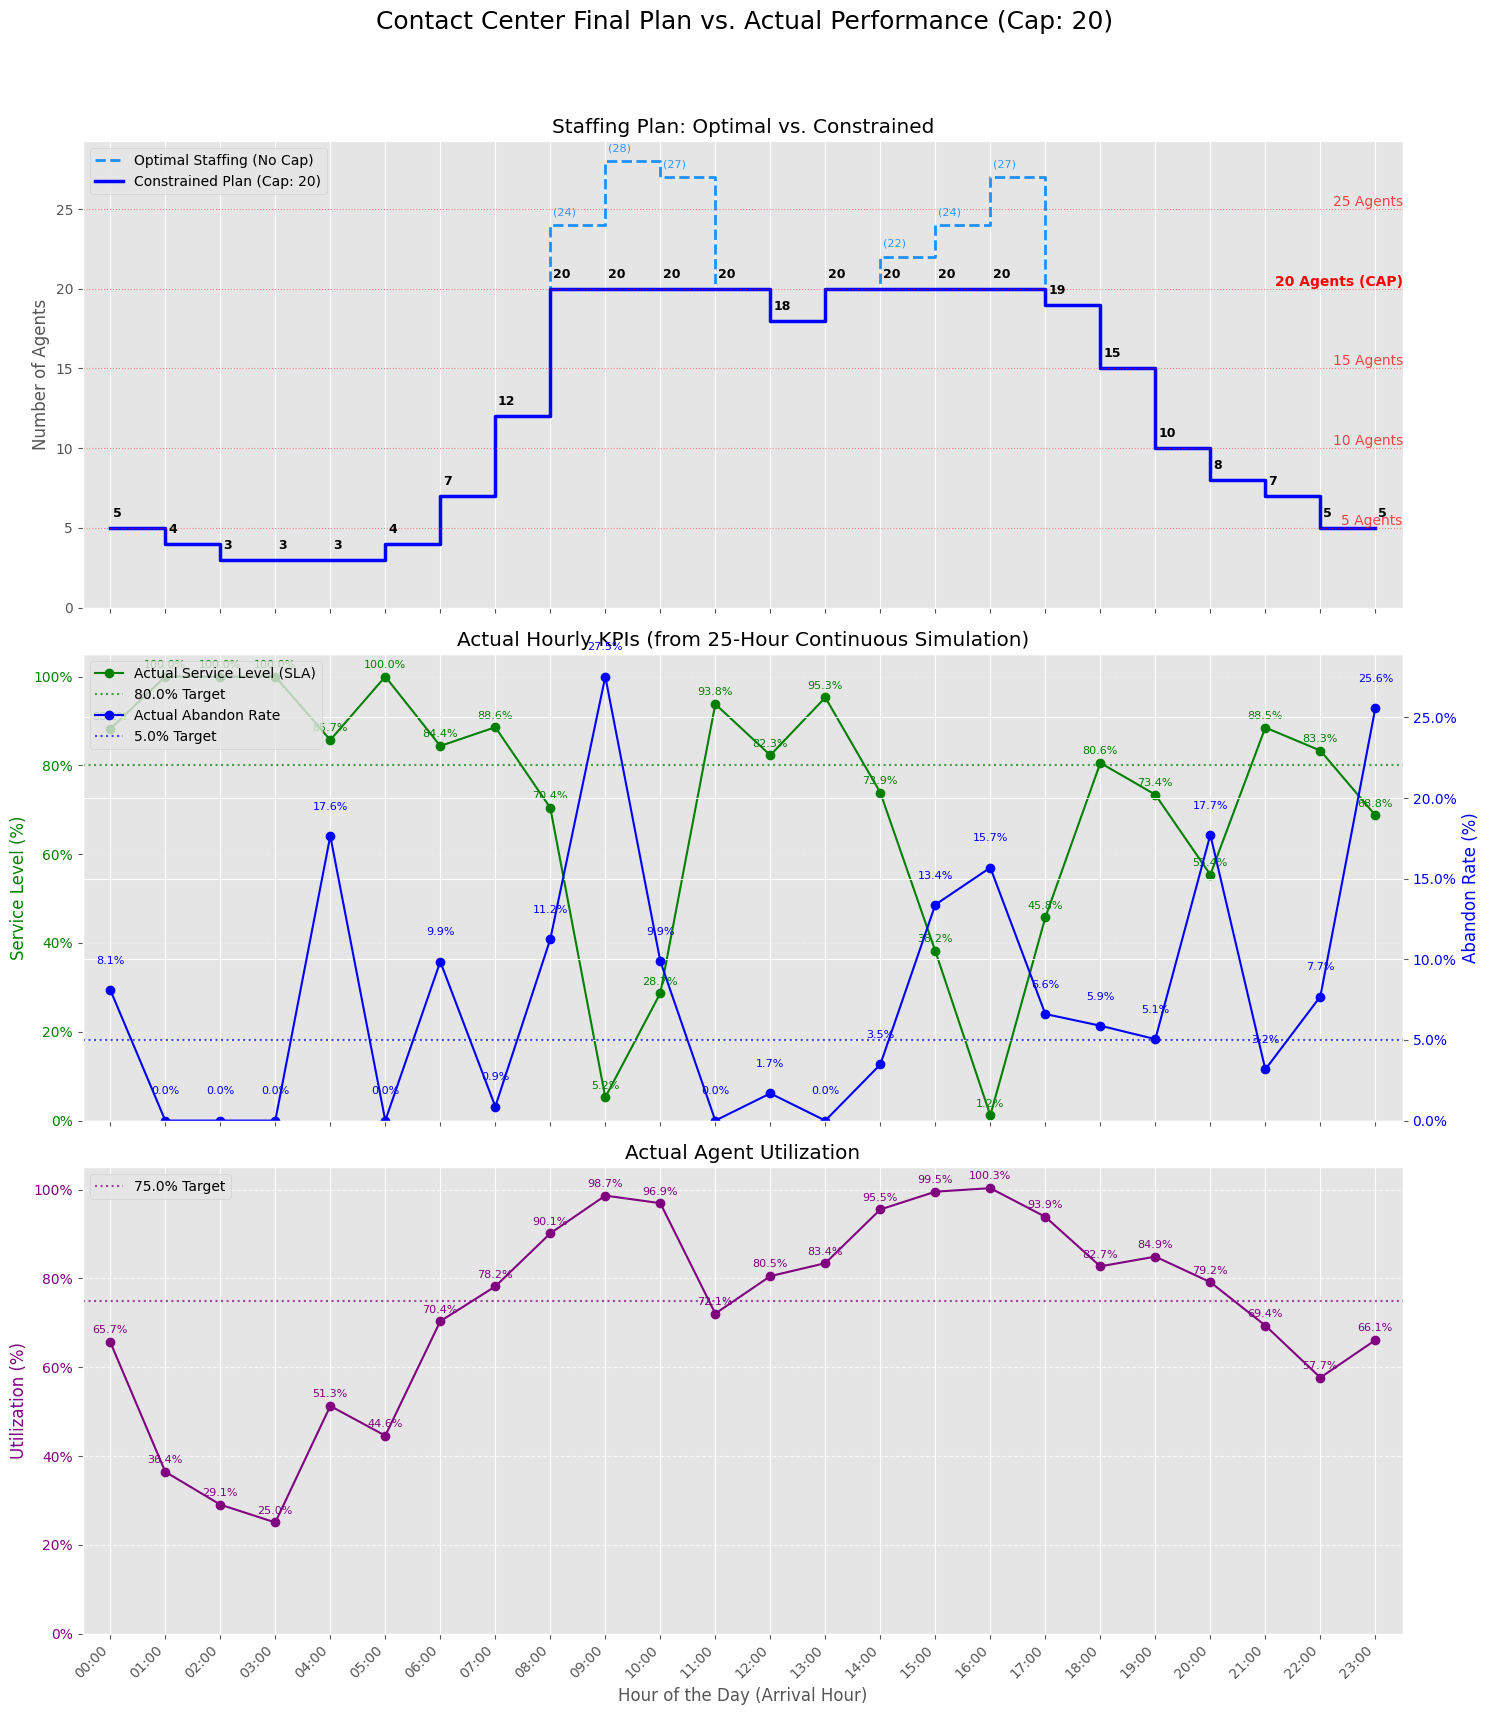

In [59]:
import simpy
import random
import statistics
import numpy as np
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- 1. GLOBAL PARAMETERS ---
PATIENCE_SECONDS = 120
SLA_THRESHOLD = 20
RANDOM_SEED = 42

# --- Optimization Parameters ---
NUM_REPLICATIONS_PER_HOUR = 100 # Replications for the *optimizer*
SIM_DURATION_PER_HOUR = 3600
AGENT_CAP = 20 # The hard limit for agents
MIN_AGENTS_TO_TEST = 1
MAX_AGENTS_TO_TEST = 30 # How high the optimizer can search

# --- Evaluation Parameters ---
SIM_DURATION_HOURS = 25 # 25-hour run to avoid end-of-run bias
SIM_DURATION_SEC = SIM_DURATION_HOURS * 3600

# --- 2. Call Arrival & Duration Models ---
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0
AVG_CALL_DURATION = 300

# --- 3. Data Structures ---
Call_Opt = namedtuple("Call", ["call_id", "arrival_time", "call_duration"])
Call_Eval = namedtuple("CallResult", [
    "call_id", "arrival_hour", "status", "wait_time", "handle_time"
])
class Agent:
    def __init__(self, agent_id):
        self.agent_id = agent_id
        self.total_handle_time = 0.0

# --- 4. KPI Collector Class (for Optimizer) ---
class KPIs_Optimizer:
    def __init__(self, agent_list):
        self.total_arrivals = 0
        self.total_answered = 0
        self.total_abandoned = 0
        self.wait_times = []
        self.sla_met_count = 0
    
    def calculate_results(self, total_sim_time):
        results = {}
        if self.total_arrivals > 0:
            results['abandon_rate'] = (self.total_abandoned / self.total_arrivals) * 100
        else:
            results['abandon_rate'] = 0.0
        if self.total_answered > 0:
            results['sla'] = (self.sla_met_count / self.total_answered) * 100
        else:
            results['sla'] = np.nan
        return results

# --- 5. Distribution Sampling Functions ---
def sample_interarrival_time_eval(current_time_seconds):
    """Samples inter-arrival time for the continuous evaluator."""
    current_hour = int(current_time_seconds // 3600) % 24
    rate_lambda = HOURLY_RATES_PER_SEC.get(current_hour, DEFAULT_RATE_PER_SEC)
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_interarrival_time_opt(rate_lambda):
    """Samples inter-arrival time for the optimizer (fixed rate)."""
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration():
    """Samples call duration (used by both)."""
    rate_lambda = 1.0 / AVG_CALL_DURATION
    return random.expovariate(rate_lambda)


#################################################################
# --- SECTION A: OPTIMIZER (Finding the Plan) ---
#################################################################

def pre_generate_calls_optimizer(sim_duration, rate_lambda):
    call_list = []
    current_time = 0.0
    while current_time < sim_duration:
        time_to_next_call = sample_interarrival_time_opt(rate_lambda)
        arrival_time = current_time + time_to_next_call
        if arrival_time > sim_duration: break
        call_duration = sample_call_duration()
        call_list.append(
            Call_Opt(call_id=0, arrival_time=arrival_time, call_duration=call_duration)
        )
        current_time = arrival_time
    return call_list

def call_process_optimizer(env, call, agent_store, kpis):
    call_duration = call.call_duration
    get_agent_request = agent_store.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)
    
    result = yield get_agent_request | patience_timeout
    if get_agent_request in result:
        agent = get_agent_request.value 
        wait_time = env.now - call.arrival_time
        kpis.total_answered += 1
        kpis.wait_times.append(wait_time)
        if wait_time <= SLA_THRESHOLD: kpis.sla_met_count += 1
        yield env.timeout(call_duration)
        yield agent_store.put(agent)
    else:
        kpis.total_abandoned += 1
        get_agent_request.cancel()

def call_generator_optimizer(env, agent_store, kpis, call_list):
    for call in call_list:
        time_to_wait = call.arrival_time - env.now
        if time_to_wait > 0: yield env.timeout(time_to_wait)
        kpis.total_arrivals += 1
        env.process(call_process_optimizer(env, call, agent_store, kpis))

def run_one_replica_optimizer(num_agents, sim_duration, rate_lambda):
    call_trace = pre_generate_calls_optimizer(sim_duration, rate_lambda)
    agent_objects = [Agent(f"Agent-{j+1}") for j in range(num_agents)]
    kpis = KPIs_Optimizer(agent_list=agent_objects)
    env = simpy.Environment()
    agent_pool = simpy.Store(env)
    agent_pool.items = agent_objects[:]
    env.process(call_generator_optimizer(env, agent_pool, kpis, call_trace))
    env.run(until=sim_duration)
    return kpis.calculate_results(sim_duration)

def check_kpis_for_n_agents_optimizer(hour, n_agents, rate_for_hour, sla_target, abandon_target):
    replication_kpis = []
    for i in range(NUM_REPLICATIONS_PER_HOUR):
        random.seed(i + hour*1000 + n_agents*100)
        kpis = run_one_replica_optimizer(
            num_agents=n_agents,
            sim_duration=SIM_DURATION_PER_HOUR,
            rate_lambda=rate_for_hour
        )
        replication_kpis.append(kpis)
    mean_sla = np.nanmean([r['sla'] for r in replication_kpis])
    mean_abandon = np.nanmean([r['abandon_rate'] for r in replication_kpis])
    is_feasible = (mean_sla >= sla_target and mean_abandon <= abandon_target)
    return is_feasible

def find_hourly_staffing_plan(sla_target=80.0, abandon_target=5.0):
    """
    Runs the binary search optimizer for each hour.
    Returns a DataFrame with 'optimal_n' and 'constrained_n'.
    """
    print("--- (1) Running Optimizer (Hourly Slices) ---")
    staffing_results = []
    for hour in range(24):
        rate_for_hour = HOURLY_RATES_PER_SEC.get(hour, DEFAULT_RATE_PER_SEC)
        if rate_for_hour <= 0:
            print(f"  Optimizing Hour {hour:02d}: No calls. Agents: 0")
            staffing_results.append({'hour': hour, 'optimal_n': 0, 'constrained_n': 0})
            continue
        print(f"  Optimizing Hour {hour:02d}...")
        low = MIN_AGENTS_TO_TEST
        high = MAX_AGENTS_TO_TEST
        optimal_n_found = np.nan
        while low <= high:
            mid_n = (low + high) // 2
            is_feasible = check_kpis_for_n_agents_optimizer(
                hour, mid_n, rate_for_hour, sla_target, abandon_target
            )
            if is_feasible:
                optimal_n_found = mid_n
                high = mid_n - 1
            else:
                low = mid_n + 1
        
        # Apply the AGENT_CAP to create the constrained plan
        constrained_n = np.nan
        if pd.isna(optimal_n_found) or optimal_n_found > AGENT_CAP:
            constrained_n = AGENT_CAP
        else:
            constrained_n = optimal_n_found
            
        staffing_results.append({
             'hour': hour, 
             'optimal_n': optimal_n_found, # The true optimal (can be > cap or NaN)
             'constrained_n': constrained_n, # The plan we will actually run
         })
    print("--- Optimizer Complete ---")
    return pd.DataFrame(staffing_results).set_index('hour')


#################################################################
# --- SECTION B: EVALUATOR (Continuous 25-hour Run) ---
#################################################################

def call_process_evaluator(env, call_id, agent_pool, results_log_list):
    arrival_time = env.now
    arrival_hour = int(arrival_time // 3600)
    get_agent_request = agent_pool.get()
    patience_timeout = env.timeout(PATIENCE_SECONDS)
    result = yield get_agent_request | patience_timeout
    if get_agent_request in result:
        agent = get_agent_request.value 
        wait_time = env.now - arrival_time
        handle_time = sample_call_duration()
        results_log_list.append(Call_Eval(
            call_id, arrival_hour, 'ANSWERED', wait_time, handle_time
        ))
        yield env.timeout(handle_time)
        yield agent_pool.put(agent)
    else:
        get_agent_request.cancel()
        results_log_list.append(Call_Eval(
            call_id, arrival_hour, 'ABANDONED', PATIENCE_SECONDS, 0
        ))

def call_generator_evaluator(env, agent_pool, results_log_list):
    call_id_counter = 0
    while env.now < SIM_DURATION_SEC:
        interarrival = sample_interarrival_time_eval(env.now)
        yield env.timeout(interarrival)
        if env.now >= SIM_DURATION_SEC: break
        call_id_counter += 1
        env.process(call_process_evaluator(env, call_id_counter, agent_pool, results_log_list))

def staffing_manager_evaluator(env, agent_pool, staffing_plan, master_agent_list):
    for hour in range(SIM_DURATION_HOURS):
        n_required = staffing_plan.get(hour % 24, 0) # Wrap for 25th hour
        n_current = len(master_agent_list)
        delta = n_required - n_current
        if delta > 0:
            for i in range(delta):
                agent = Agent(f"Agent-{hour}-{i}")
                master_agent_list.append(agent)
                yield agent_pool.put(agent)
        elif delta < 0:
            for _ in range(abs(delta)):
                env.process(remove_agent_evaluator(env, agent_pool, master_agent_list))
        yield env.timeout(3600)

def remove_agent_evaluator(env, agent_pool, master_agent_list):
    agent = yield agent_pool.get()
    master_agent_list.remove(agent)

def run_continuous_evaluation(staffing_plan_dict):
    """
    Runs the 25-hour continuous simulation using the provided plan.
    Returns a DataFrame of the *actual* hourly KPIs.
    """
    print(f"\n--- (2) Running 25-Hour Continuous Evaluation ---")
    print(f"Testing plan: {staffing_plan_dict}")
    
    results_log_list = []
    master_agent_list = [] 
    env = simpy.Environment()
    agent_pool = simpy.Store(env)
    
    env.process(staffing_manager_evaluator(env, agent_pool, staffing_plan_dict, master_agent_list))
    env.process(call_generator_evaluator(env, agent_pool, results_log_list))
    
    env.run()
    print("--- Evaluation Complete ---")

    # --- Analyze the results ---
    print("Calculating final KPIs...")
    df = pd.DataFrame(results_log_list)
    hourly_stats = []
    
    for hour in range(24): # Only analyze 0-23
        df_hour = df[df['arrival_hour'] == hour]
        
        total_calls = len(df_hour)
        answered = (df_hour['status'] == 'ANSWERED').sum()
        abandoned = (df_hour['status'] == 'ABANDONED').sum()
        
        if answered > 0:
            sla_met = (df_hour[df_hour['status'] == 'ANSWERED']['wait_time'] <= SLA_THRESHOLD).sum()
            sla = (sla_met / answered) * 100
        else:
            sla = np.nan
            
        if total_calls > 0:
            abandon_rate = (abandoned / total_calls) * 100
        else:
            abandon_rate = 0.0
            
        agents_this_hour = staffing_plan_dict.get(hour, 0)
        if agents_this_hour > 0:
            total_handle_time_this_hour = df_hour['handle_time'].sum()
            total_seconds_available = agents_this_hour * 3600
            utilization = (total_handle_time_this_hour / total_seconds_available) * 100
        else:
            utilization = 0.0
            
        hourly_stats.append({
            'hour': hour,
            'sla': sla,
            'abandon_rate': abandon_rate,
            'utilization': utilization,
        })
        
    return pd.DataFrame(hourly_stats).set_index('hour')


#################################################################
# --- SECTION C: PLOTTING ---
#################################################################

def plot_final_dashboard(optimizer_df, evaluator_df, sla_target=80.0, abandon_target=5.0, util_target=75.0):
    """
    Creates the 3-panel dashboard.
    - optimizer_df: Contains the 'optimal_n' and 'constrained_n'.
    - evaluator_df: Contains the *actual* 'sla', 'abandon_rate', 'utilization'.
    """
    print("\n--- (3) Generating Final Dashboard ---")
    
    fig, (ax_agents, ax_kpis, ax_util) = plt.subplots(
        nrows=3, ncols=1, figsize=(15, 18), 
        sharex=True, gridspec_kw={'height_ratios': [1, 1, 1]}
    )
    fig.suptitle(f'Contact Center Final Plan vs. Actual Performance (Cap: {AGENT_CAP})', fontsize=18)
    
    hours = optimizer_df.index.values

    # --- Top Panel: The Staffing Plan We Tested ---
    ax_agents.step(hours, optimizer_df['optimal_n'], where='post', color='dodgerblue', 
                   linestyle='--', linewidth=2, label='Optimal Staffing (No Cap)')
    
    ax_agents.step(hours, optimizer_df['constrained_n'], where='post', color='blue', 
                   linestyle='-', linewidth=2.5, label=f'Constrained Plan (Cap: {AGENT_CAP})')
    
    # Add text labels for *constrained* plan
    for h, n in zip(hours, optimizer_df['constrained_n']):
        if not pd.isna(n) and n > 0:
            ax_agents.text(h + 0.05, n + 0.5, f'{int(n)}', 
                           verticalalignment='bottom', horizontalalignment='left',
                           color='black', fontsize=9, fontweight='bold')
    
    # Add text labels for *optimal* plan (only if different)
    for h, n_opt, n_con in zip(hours, optimizer_df['optimal_n'], optimizer_df['constrained_n']):
        if not pd.isna(n_opt) and n_opt > 0 and n_opt != n_con:
            ax_agents.text(h + 0.05, n_opt + 0.5, f'({int(n_opt)})', 
                           verticalalignment='bottom', horizontalalignment='left',
                           color='dodgerblue', fontsize=8, alpha=0.9)

    for n in [5, 10, 15, 20, 25]:
        ax_agents.axhline(y=n, color='red', linestyle=':', alpha=0.5, linewidth=0.8)
        if n == AGENT_CAP:
             ax_agents.text(23.5, n, f'{n} Agents (CAP)', color='red', 
                           horizontalalignment='right', verticalalignment='bottom',
                           fontweight='bold')
        else:
             ax_agents.text(23.5, n, f'{n} Agents', color='red', alpha=0.7, 
                           horizontalalignment='right', verticalalignment='bottom')

    ax_agents.set_title('Staffing Plan: Optimal vs. Constrained')
    ax_agents.set_ylabel('Number of Agents')
    ax_agents.grid(axis='y', linestyle='--', alpha=0.7)
    ax_agents.set_ylim(bottom=0)
    ax_agents.legend(loc='upper left')
    ax_agents.set_xlim(-0.5, 23.5)

    # --- Middle Panel: Actual Resulting KPIs ---
    ax_abandon = ax_kpis.twinx()

    ax_kpis.plot(evaluator_df.index, evaluator_df['sla'], color='green', marker='o', linestyle='-', label='Actual Service Level (SLA)')
    ax_kpis.axhline(y=sla_target, color='green', linestyle=':', alpha=0.7, label=f'{sla_target}% Target')
    ax_kpis.set_ylabel('Service Level (%)', color='green')
    ax_kpis.tick_params(axis='y', labelcolor='green')
    ax_kpis.set_ylim(0, 105)
    
    ax_abandon.plot(evaluator_df.index, evaluator_df['abandon_rate'], color='blue', marker='o', linestyle='-', label='Actual Abandon Rate')
    ax_abandon.axhline(y=abandon_target, color='blue', linestyle=':', alpha=0.7, label=f'{abandon_target}% Target')
    ax_abandon.set_ylabel('Abandon Rate (%)', color='blue')
    ax_abandon.tick_params(axis='y', labelcolor='blue')
    ax_abandon.set_ylim(bottom=0)

    for h, sla_val, abandon_val in zip(hours, evaluator_df['sla'], evaluator_df['abandon_rate']):
        if not pd.isna(sla_val):
            ax_kpis.text(h, sla_val + 1.5, f'{sla_val:.1f}%', va='bottom', ha='center', color='green', fontsize=8)
        if not pd.isna(abandon_val):
            ax_abandon.text(h, abandon_val + 1.5, f'{abandon_val:.1f}%', va='bottom', ha='center', color='blue', fontsize=8)

    ax_kpis.set_title('Actual Hourly KPIs (from 25-Hour Continuous Simulation)')
    ax_kpis.grid(axis='y', linestyle='--', alpha=0.2)
    ax_kpis.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_abandon.yaxis.set_major_formatter(mtick.PercentFormatter())
    
    lines_sla, labels_sla = ax_kpis.get_legend_handles_labels()
    lines_abandon, labels_abandon = ax_abandon.get_legend_handles_labels()
    ax_abandon.legend(lines_sla + lines_abandon, labels_sla + labels_abandon, loc='upper left')

    # --- Bottom Panel: Actual Agent Utilization ---
    ax_util.plot(evaluator_df.index, evaluator_df['utilization'], color='purple', marker='o', linestyle='-')
    ax_util.axhline(y=util_target, color='purple', linestyle=':', alpha=0.7, label=f'{util_target}% Target')
    
    ax_util.set_title('Actual Agent Utilization')
    ax_util.set_ylabel('Utilization (%)', color='purple')
    ax_util.tick_params(axis='y', labelcolor='purple')
    ax_util.set_ylim(0, 105)
    ax_util.grid(axis='y', linestyle='--', alpha=0.7)
    ax_util.legend(loc='upper left')
    
    for h, util_val in zip(hours, evaluator_df['utilization']):
        if not pd.isna(util_val):
            ax_util.text(h, util_val + 1.5, f'{util_val:.1f}%', va='bottom', ha='center', color='purple', fontsize=8)
    
    ax_util.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax_util.set_xlabel('Hour of the Day (Arrival Hour)')
    ax_util.set_xticks(np.arange(0, 24, 1))
    ax_util.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha='right')
    ax_util.set_xlim(-0.5, 23.5)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('final_simulation_dashboard.png')
    print("Dashboard plot saved to 'final_simulation_dashboard.png'")


#################################################################
# --- SECTION D: MAIN EXECUTION ---
#################################################################
if __name__ == "__main__":
    random.seed(RANDOM_SEED)
    
    # --- STEP 1: Run the optimizer to get the plan ---
    # This plan contains 'optimal_n' and 'constrained_n'
    optimizer_results_df = find_hourly_staffing_plan(
        sla_target=80.0, 
        abandon_target=5.0
    )
    
    # --- STEP 2: Extract the plan to be tested ---
    # We test the plan that respects the AGENT_CAP
    plan_to_evaluate = optimizer_results_df['constrained_n'].to_dict()
    
    # --- STEP 3: Run the continuous evaluator ---
    # This runs the 25-hour simulation to get *actual* KPIs
    evaluator_results_df = run_continuous_evaluation(
        staffing_plan_dict=plan_to_evaluate
    )
    
    # --- STEP 4: Plot the final dashboard ---
    print("\n--- Optimizer Plan (for plotting) ---")
    print(optimizer_results_df)
    print("\n--- Evaluator Results (Actual KPIs) ---")
    print(evaluator_results_df)

    plot_final_dashboard(
        optimizer_df=optimizer_results_df,
        evaluator_df=evaluator_results_df,
        sla_target=80.0, 
        abandon_target=5.0, 
        util_target=75.0
    )

In [71]:
import simpy
import random
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simpy_helpers import Entity, Source, Stats

# --- 1. Global Simulation Parameters ---
# (Used in the __main__ block to feed the simulators)

# Call center targets
PATIENCE_SECONDS = 120
SLA_THRESHOLD = 20

# Call behavior
AVG_CALL_DURATION = 300
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0


# --- 2. Common Components ---

def sample_interarrival_time(rate_lambda):
    """Samples from an exponential distribution."""
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration(avg_call_duration):
    """Samples from an exponential distribution for call duration."""
    rate_lambda = 1.0 / avg_call_duration
    return random.expovariate(rate_lambda)

class KPIs:
    """Manual KPI collector for SLA and Abandon stats."""
    def __init__(self, sla_threshold):
        self.total_arrivals = 0
        self.total_answered = 0
        self.total_abandoned = 0
        self.wait_times = []
        self.sla_met_count = 0
        self.sla_threshold = sla_threshold

    def calculate_results(self):
        results = {}
        if self.total_arrivals > 0:
            results['abandon_rate'] = (self.total_abandoned / self.total_arrivals) * 100
        else:
            results['abandon_rate'] = 0.0

        if self.total_answered > 0:
            results['asa'] = statistics.mean(self.wait_times)
            results['sla'] = (self.sla_met_count / self.total_answered) * 100
        else:
            results['asa'] = np.nan
            results['sla'] = np.nan
        return results

class Agent:
    """Agent class for the dynamic 24-hour sim."""
    def __init__(self, agent_id):
        self.agent_id = agent_id

# --- 3. Helper Function to Print Reports ---

def print_kpi_report(name, results_df, n_replications):
    """Helper function to calculate and print Mean/95% CI."""
    
    # Calculate Mean KPIs
    mean_kpis = {
        'sla': results_df['sla'].mean(),
        'abandon_rate': results_df['abandon_rate'].mean(),
        'asa': results_df['asa'].mean(),
        'total_arrivals': results_df['total_arrivals'].mean(),
    }
    
    # Calculate 95% Confidence Intervals
    ci_kpis = {}
    if n_replications > 1:
        z_score = 1.96  # For 95% CI
        n_sqrt = np.sqrt(n_replications)
        
        for col in ['sla', 'abandon_rate', 'asa']:
            if results_df[col].isnull().all():
                ci_kpis[col] = (np.nan, np.nan)
                continue
            std_dev = results_df[col].std()
            margin_of_error = z_score * (std_dev / n_sqrt)
            ci_kpis[col] = (mean_kpis[col] - margin_of_error, mean_kpis[col] + margin_of_error)
    else:
        for col in ['sla', 'abandon_rate', 'asa']:
            ci_kpis[col] = (np.nan, np.nan)

    # --- Print Final Report ---
    print(f"\n--- {name} KPI Report ---")
    print(f"  (Based on {n_replications} replications)")
    print(f"\n  Service Level (SLA):")
    print(f"    Mean:           {mean_kpis['sla']:.2f}%")
    print(f"    95% CI Range:   [{ci_kpis['sla'][0]:.2f}% - {ci_kpis['sla'][1]:.2f}%]")
    
    print(f"\n  Abandon Rate:")
    print(f"    Mean:           {mean_kpis['abandon_rate']:.2f}%")
    print(f"    95% CI Range:   [{ci_kpis['abandon_rate'][0]:.2f}% - {ci_kpis['abandon_rate'][1]:.2f}%]")
    
    print(f"\n  Average Speed of Answer (ASA):")
    print(f"    Mean:           {mean_kpis['asa']:.2f} sec")
    print(f"    95% CI Range:   [{ci_kpis['asa'][0]:.2f} - {ci_kpis['asa'][1]:.2f}] sec")
    
    print(f"\n  Average Arrivals:")
    print(f"    Mean:           {mean_kpis['total_arrivals']:.1f}")


# ======================================================================
# --- SIMULATOR 1: HOURLY BLACK BOX ---
# ======================================================================

class FixedPoolCallEntity(Entity):
    """
    Entity for a simulation with a fixed-capacity 'simpy.Resource'.
    """
    def process(self):
        # Get args from Source
        agent_pool = self.entity_args['agent_pool']
        kpis = self.entity_args['kpis']
        stats = self.entity_args['stats']
        patience = self.entity_args['patience']
        
        # Get attributes from Source
        call_duration = self.attributes['call_duration']
        arrival_time = self.env.now
        
        # Use simpy.Resource
        with agent_pool.request() as req:
            patience_timeout = self.env.timeout(patience)
            result = yield req | patience_timeout
            
            wait_time = self.env.now - arrival_time
            
            if req in result:
                kpis.total_answered += 1
                kpis.wait_times.append(wait_time)
                if wait_time <= kpis.sla_threshold:
                    kpis.sla_met_count += 1
                
                stats.completed_entities += 1
                
                yield self.env.timeout(call_duration)
            else:
                kpis.total_abandoned += 1

def run_one_hourly_sim(seed, num_agents, rate_lambda, sla_threshold, 
                       patience, avg_call_duration):
    """Factory to create one 1-hour simulation environment."""
    random.seed(seed)
    env = simpy.Environment()
    
    kpis = KPIs(sla_threshold)
    stats = Stats()
    
    # 1. Create a standard simpy.Resource
    agent_pool = simpy.Resource(env, capacity=num_agents)
    
    # 2. Attach the Stats object using the correct method name: 'add_resource'
    try:
        stats.add_resource(agent_pool)
    except Exception as e:
        print(f"Warning: Could not attach stats to resource. Stats wrapper might be incompatible. Error: {e}")

    def increment_arrivals(entity):
        kpis.total_arrivals += 1
        
    # Create one Source for the whole hour
    Source(
        env,
        # --- THIS IS THE FIX ---
        # Removed the interarrival_time argument entirely
        entity_type=FixedPoolCallEntity,
        entity_args={
            'agent_pool': agent_pool,
            'kpis': kpis,
            'stats': stats,
            'patience': patience
        },
        entity_attributes={
            'call_duration': lambda: sample_call_duration(avg_call_duration)
        },
        stop_time=3600, # Run for 1 hour
        on_create=increment_arrivals
        # Assuming the default interarrival relies on overriding a method
        # or maybe uses a default of 0? We need to see if it runs.
        # If it needs a specific argument, we'll get another TypeError.
    ).start()
    
    env.run()
    
    results = kpis.calculate_results()
    results['total_arrivals'] = kpis.total_arrivals
    try:
        results['utilization'] = stats.get_utilization(env.now) * 100
    except Exception as e:
        print(f"Warning: Could not get utilization. Error: {e}")
        results['utilization'] = np.nan
    
    return results

def run_hourly_replications(hour, num_agents, n_replications, base_seed,
                            sla_threshold, patience, avg_call_duration):
    """
    BLACK BOX 1: Simulates a single hour N times.
    """
    print(f"--- Starting Hourly Black Box Simulation ---")
    print(f"Testing Hour {hour} with {num_agents} agents ({n_replications} replications)...")
    
    rate_for_hour = HOURLY_RATES_PER_SEC.get(hour, DEFAULT_RATE_PER_SEC)
    if rate_for_hour <= 0:
        print("No calls expected for this hour.")
        return
        
    all_results = []
    
    for i in range(n_replications):
        rep_seed = base_seed + i
        sim_results = run_one_hourly_sim(
            seed=rep_seed,
            num_agents=num_agents,
            rate_lambda=rate_for_hour, # Still needed to pass down eventually?
            sla_threshold=sla_threshold,
            patience=patience,
            avg_call_duration=avg_call_duration
        )
        all_results.append(sim_results)

    results_df = pd.DataFrame(all_results)
    print_kpi_report(f"Hourly (Hour {hour}, N={num_agents})", results_df, n_replications)
    
    # Print utilization specific to this simulator
    print(f"  Average Agent Utilization: {results_df['utilization'].mean():.2f}%")
    
    return results_df


# ======================================================================
# --- SIMULATOR 2: 24-HOUR BLOCK SHIFT BLACK BOX ---
# ======================================================================

class DynamicPoolCallEntity(Entity):
    """
    Entity for a simulation with a dynamic 'simpy.Store' agent pool.
    """
    def process(self):
        # Get args
        agent_store = self.entity_args['agent_store']
        kpis = self.entity_args['kpis']
        stats = self.entity_args['stats']
        patience = self.entity_args['patience']
        
        # Get attribute
        call_duration = self.attributes['call_duration']
        arrival_time = self.env.now
        
        # We MUST use simpy.Store for a dynamic pool
        get_agent_request = agent_store.get()
        patience_timeout = self.env.timeout(patience)
        
        result = yield get_agent_request | patience_timeout
        
        if get_agent_request in result:
            agent = get_agent_request.value 
            wait_time = self.env.now - arrival_time
            
            kpis.total_answered += 1
            kpis.wait_times.append(wait_time)
            if wait_time <= kpis.sla_threshold: 
                kpis.sla_met_count += 1
            
            stats.completed_entities += 1
            
            yield self.env.timeout(call_duration)
            yield agent_store.put(agent) # Return agent to the dynamic pool
        else:
            kpis.total_abandoned += 1
            get_agent_request.cancel()

def hourly_source_controller(env, hourly_rates, agent_store, kpis, stats, 
                             avg_call_duration, patience, default_rate):
    """Launches a new sh.Source for each hour."""
    def increment_arrivals(entity):
        kpis.total_arrivals += 1

    for hour in range(24):
        current_time = env.now
        rate_lambda = hourly_rates.get(hour, default_rate)
        
        if rate_lambda > 0:
            # Need to figure out how to pass the rate_lambda now...
            # This Source likely won't work correctly without interarrival specified.
            # For now, let's keep the removal, but this might break functionality.
            Source(
                env,
                # --- THIS IS THE FIX ---
                # Removed the interarrival_time argument entirely
                entity_type=DynamicPoolCallEntity,
                entity_args={
                    'agent_store': agent_store,
                    'kpis': kpis,
                    'stats': stats,
                    'patience': patience,
                    # We might need to pass rate_lambda here if Entity needs it?
                },
                entity_attributes={
                    'call_duration': lambda: sample_call_duration(avg_call_duration)
                },
                stop_time=current_time + 3600,
                on_create=increment_arrivals
            ).start()
        
        yield env.timeout(3600)

def staffing_controller(env, staffing_plan_dict, agent_store, agent_id_counter):
    """Adjusts agents in the simpy.Store based on a 24-hour dictionary plan."""
    for hour in range(24):
        required_n = staffing_plan_dict.get(hour, 0)
        current_n = len(agent_store.items)
        diff = required_n - current_n
        
        if diff > 0:
            for _ in range(diff):
                agent_id_counter[0] += 1
                agent = Agent(f"DaySim-Agent-{agent_id_counter[0]}")
                yield agent_store.put(agent)
        elif diff < 0:
            for _ in range(abs(diff)):
                yield agent_store.get()
        
        yield env.timeout(3600)

def convert_block_plan_to_hourly(block_plan, default_agents=0):
    """
    Converts a list of shifts into a 24-hour dictionary.
    Example block_plan: [(9, 17, 20), (22, 6, 10)]
    (9, 17, 20) means 20 agents from 9:00 to 16:59.
    (22, 6, 10) means 10 agents from 22:00 to 05:59.
    """
    hourly_plan = {}
    for hour in range(24):
        hourly_plan[hour] = default_agents
        for (start, end, agents) in block_plan:
            if start < end: # Normal day shift (e.g., 9-17)
                if start <= hour < end:
                    hourly_plan[hour] = agents
                    break
            else: # Overnight shift (e.g., 22-6)
                if hour >= start or hour < end:
                    hourly_plan[hour] = agents
                    break
    return hourly_plan

def run_one_day_simulation(staffing_plan_dict, seed, patience, sla_threshold, 
                           hourly_rates, avg_call_duration, default_rate):
    """Runs a single 24-hour simulation."""
    random.seed(seed)
    np.random.seed(seed)
    
    env = simpy.Environment()
    agent_store = simpy.Store(env)
    
    kpis = KPIs(sla_threshold)
    stats = Stats()
    
    agent_id_counter = [0]

    env.process(staffing_controller(
        env, staffing_plan_dict, agent_store, agent_id_counter
    ))
    env.process(hourly_source_controller(
        env, hourly_rates, agent_store, kpis, stats,
        avg_call_duration, patience, default_rate
    ))
    
    env.run(until=24 * 3600)
    
    results = kpis.calculate_results()
    results['total_arrivals'] = kpis.total_arrivals
    results['total_answered'] = kpis.total_answered
    results['total_abandoned'] = kpis.total_abandoned
    return results

def run_block_shift_replications(block_shift_plan, n_replications, base_seed,
                                 patience, sla_threshold, hourly_rates,
                                 avg_call_duration, default_rate, default_agents=0):
    """
    BLACK BOX 2: Simulates a 24-hour day N times using a block shift plan.
    """
    print(f"\n--- Starting 24-Hour Block Shift Black Box Simulation ---")
    print(f"Testing block plan for {n_replications} replications...")
    
    # --- Convert block plan to hourly plan ---
    staffing_plan_dict = convert_block_plan_to_hourly(block_shift_plan, default_agents)
    print("  Interpreted hourly plan:")
    print("  " + ", ".join(f"{h:02d}:00={n}" for h, n in staffing_plan_dict.items()))
    
    all_results = []
    
    for i in range(n_replications):
        rep_seed = base_seed + i
        day_results = run_one_day_simulation(
            staffing_plan_dict, rep_seed, patience, sla_threshold, 
            hourly_rates, avg_call_duration, default_rate
        )
        all_results.append(day_results)
        
        if (i + 1) % (n_replications // 5 or 1) == 0:
             print(f"  Completed replication {i + 1}/{n_replications}...")

    results_df = pd.DataFrame(all_results)
    print_kpi_report("24-Hour Block Shift", results_df, n_replications)
    return results_df


# ======================================================================
# --- MAIN EXECUTION ---
# ======================================================================

if __name__ == "__main__":
    
    # --- Demo 1: Run the Hourly Simulator ---
    # Test a single, high-volume hour (9:00 AM)
    #
    run_hourly_replications(
        hour=9, 
        num_agents=28,  # Let's test with 28 agents
        n_replications=100,
        base_seed=42,
        sla_threshold=SLA_THRESHOLD,
        patience=PATIENCE_SECONDS,
        avg_call_duration=AVG_CALL_DURATION
    )

    # --- Demo 2: Run the Block Shift Simulator ---
    #
    # Define a simplified 3-shift plan
    # (start_hour, end_hour_exclusive, num_agents)
    my_block_plan = [
        (9, 17, 30),     # 9:00 AM - 4:59 PM: 30 agents (Day Shift)
        (17, 23, 20),    # 5:00 PM - 10:59 PM: 20 agents (Swing Shift)
        (23, 9, 10)      # 11:00 PM - 8:59 AM: 10 agents (Overnight Shift)
    ]
    
    run_block_shift_replications(
        block_shift_plan=my_block_plan,
        n_replications=100,
        base_seed=42,
        patience=PATIENCE_SECONDS,
        sla_threshold=SLA_THRESHOLD,
        hourly_rates=HOURLY_RATES_PER_SEC,
        avg_call_duration=AVG_CALL_DURATION,
        default_rate=DEFAULT_RATE_PER_SEC,
        default_agents=0  # Agents on shift if not in a defined block
    )

--- Starting Hourly Black Box Simulation ---
Testing Hour 9 with 28 agents (100 replications)...


TypeError: Source.__init__() got an unexpected keyword argument 'entity_type'

--- Starting Hourly Black Box Simulation ---
Testing Hour 9 with 28 agents (100 replications)...


TypeError: Source.__init__() got an unexpected keyword argument 'interarrival_time'

In [ ]:
import simpy
import random
import statistics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from simpy_helpers import Entity, Source, Stats

# --- 1. Global Simulation Parameters ---
# (Used in the __main__ block to feed the simulators)

# Call center targets
PATIENCE_SECONDS = 120
SLA_THRESHOLD = 20

# Call behavior
AVG_CALL_DURATION = 300
HOURLY_CALL_RATES = {
    0: 30, 1: 20, 2: 10, 3: 10, 4: 15, 5: 30, 6: 60, 7: 120,
    8: 250, 9: 300, 10: 280, 11: 200, 12: 180, 13: 200, 14: 220,
    15: 250, 16: 280, 17: 200, 18: 150, 19: 100, 20: 80, 21: 60, 22: 40, 23: 30
}
HOURLY_RATES_PER_SEC = {
    hour: rate / 3600.0 for hour, rate in HOURLY_CALL_RATES.items()
}
DEFAULT_RATE_PER_SEC = 10 / 3600.0


# --- 2. Common Components ---

def sample_interarrival_time(rate_lambda):
    """Samples from an exponential distribution."""
    if rate_lambda <= 0: return 999999
    return random.expovariate(rate_lambda)

def sample_call_duration(avg_call_duration):
    """Samples from an exponential distribution for call duration."""
    rate_lambda = 1.0 / avg_call_duration
    return random.expovariate(rate_lambda)

class KPIs:
    """Manual KPI collector for SLA and Abandon stats."""
    def __init__(self, sla_threshold):
        self.total_arrivals = 0
        self.total_answered = 0
        self.total_abandoned = 0
        self.wait_times = []
        self.sla_met_count = 0
        self.sla_threshold = sla_threshold

    def calculate_results(self):
        results = {}
        if self.total_arrivals > 0:
            results['abandon_rate'] = (self.total_abandoned / self.total_arrivals) * 100
        else:
            results['abandon_rate'] = 0.0

        if self.total_answered > 0:
            results['asa'] = statistics.mean(self.wait_times)
            results['sla'] = (self.sla_met_count / self.total_answered) * 100
        else:
            results['asa'] = np.nan
            results['sla'] = np.nan
        return results

class Agent:
    """Agent class for the dynamic 24-hour sim."""
    def __init__(self, agent_id):
        self.agent_id = agent_id

# --- 3. Helper Function to Print Reports ---

def print_kpi_report(name, results_df, n_replications):
    """Helper function to calculate and print Mean/95% CI."""
    
    # Calculate Mean KPIs
    mean_kpis = {
        'sla': results_df['sla'].mean(),
        'abandon_rate': results_df['abandon_rate'].mean(),
        'asa': results_df['asa'].mean(),
        'total_arrivals': results_df['total_arrivals'].mean(),
    }
    
    # Calculate 95% Confidence Intervals
    ci_kpis = {}
    if n_replications > 1:
        z_score = 1.96  # For 95% CI
        n_sqrt = np.sqrt(n_replications)
        
        for col in ['sla', 'abandon_rate', 'asa']:
            if results_df[col].isnull().all():
                ci_kpis[col] = (np.nan, np.nan)
                continue
            std_dev = results_df[col].std()
            margin_of_error = z_score * (std_dev / n_sqrt)
            ci_kpis[col] = (mean_kpis[col] - margin_of_error, mean_kpis[col] + margin_of_error)
    else:
        for col in ['sla', 'abandon_rate', 'asa']:
            ci_kpis[col] = (np.nan, np.nan)

    # --- Print Final Report ---
    print(f"\n--- {name} KPI Report ---")
    print(f"  (Based on {n_replications} replications)")
    print(f"\n  Service Level (SLA):")
    print(f"    Mean:           {mean_kpis['sla']:.2f}%")
    print(f"    95% CI Range:   [{ci_kpis['sla'][0]:.2f}% - {ci_kpis['sla'][1]:.2f}%]")
    
    print(f"\n  Abandon Rate:")
    print(f"    Mean:           {mean_kpis['abandon_rate']:.2f}%")
    print(f"    95% CI Range:   [{ci_kpis['abandon_rate'][0]:.2f}% - {ci_kpis['abandon_rate'][1]:.2f}%]")
    
    print(f"\n  Average Speed of Answer (ASA):")
    print(f"    Mean:           {mean_kpis['asa']:.2f} sec")
    print(f"    95% CI Range:   [{ci_kpis['asa'][0]:.2f} - {ci_kpis['asa'][1]:.2f}] sec")
    
    print(f"\n  Average Arrivals:")
    print(f"    Mean:           {mean_kpis['total_arrivals']:.1f}")


# ======================================================================
# --- SIMULATOR 1: HOURLY BLACK BOX ---
# ======================================================================

class FixedPoolCallEntity(Entity):
    """
    Entity for a simulation with a fixed-capacity 'simpy.Resource'.
    """
    def process(self):
        # Get args from Source
        agent_pool = self.entity_args['agent_pool']
        kpis = self.entity_args['kpis']
        stats = self.entity_args['stats']
        patience = self.entity_args['patience']
        
        # Get attributes from Source
        call_duration = self.attributes['call_duration']
        arrival_time = self.env.now
        
        # Use simpy.Resource
        with agent_pool.request() as req:
            patience_timeout = self.env.timeout(patience)
            result = yield req | patience_timeout
            
            wait_time = self.env.now - arrival_time
            
            if req in result:
                kpis.total_answered += 1
                kpis.wait_times.append(wait_time)
                if wait_time <= kpis.sla_threshold:
                    kpis.sla_met_count += 1
                
                stats.completed_entities += 1
                
                yield self.env.timeout(call_duration)
            else:
                kpis.total_abandoned += 1

def run_one_hourly_sim(seed, num_agents, rate_lambda, sla_threshold, 
                       patience, avg_call_duration):
    """Factory to create one 1-hour simulation environment."""
    random.seed(seed)
    env = simpy.Environment()
    
    kpis = KPIs(sla_threshold)
    stats = Stats()
    
    # 1. Create a standard simpy.Resource
    agent_pool = simpy.Resource(env, capacity=num_agents)
    
    # 2. Attach the Stats object using the correct method name: 'add_resource'
    try:
        stats.add_resource(agent_pool)
    except Exception as e:
        print(f"Warning: Could not attach stats to resource. Stats wrapper might be incompatible. Error: {e}")

    def increment_arrivals(entity):
        kpis.total_arrivals += 1
        
    # Create one Source for the whole hour
    Source(
        env,
        # --- THIS IS THE FIX ---
        # Removed the interarrival_time argument entirely
        entity_type=FixedPoolCallEntity,
        entity_args={
            'agent_pool': agent_pool,
            'kpis': kpis,
            'stats': stats,
            'patience': patience
        },
        entity_attributes={
            'call_duration': lambda: sample_call_duration(avg_call_duration)
        },
        stop_time=3600, # Run for 1 hour
        on_create=increment_arrivals
        # Assuming the default interarrival relies on overriding a method
        # or maybe uses a default of 0? We need to see if it runs.
        # If it needs a specific argument, we'll get another TypeError.
    ).start()
    
    env.run()
    
    results = kpis.calculate_results()
    results['total_arrivals'] = kpis.total_arrivals
    try:
        results['utilization'] = stats.get_utilization(env.now) * 100
    except Exception as e:
        print(f"Warning: Could not get utilization. Error: {e}")
        results['utilization'] = np.nan
    
    return results

def run_hourly_replications(hour, num_agents, n_replications, base_seed,
                            sla_threshold, patience, avg_call_duration):
    """
    BLACK BOX 1: Simulates a single hour N times.
    """
    print(f"--- Starting Hourly Black Box Simulation ---")
    print(f"Testing Hour {hour} with {num_agents} agents ({n_replications} replications)...")
    
    rate_for_hour = HOURLY_RATES_PER_SEC.get(hour, DEFAULT_RATE_PER_SEC)
    if rate_for_hour <= 0:
        print("No calls expected for this hour.")
        return
        
    all_results = []
    
    for i in range(n_replications):
        rep_seed = base_seed + i
        sim_results = run_one_hourly_sim(
            seed=rep_seed,
            num_agents=num_agents,
            rate_lambda=rate_for_hour, # Still needed to pass down eventually?
            sla_threshold=sla_threshold,
            patience=patience,
            avg_call_duration=avg_call_duration
        )
        all_results.append(sim_results)

    results_df = pd.DataFrame(all_results)
    print_kpi_report(f"Hourly (Hour {hour}, N={num_agents})", results_df, n_replications)
    
    # Print utilization specific to this simulator
    print(f"  Average Agent Utilization: {results_df['utilization'].mean():.2f}%")
    
    return results_df